# 02 Stage 1 Preprocessing for Clustering

This notebook implements stage 1 from `CLUSTERING_STAGE1_PLAN.md`.

Goal:
- clean the train feature space,
- combine statistical filtering with financial-domain review,
- build reproducible preprocessing candidates,
- prepare a reusable stage-1 artifact for later `joblib` export.

This notebook is not for final cluster selection, cluster-ID prediction, or subgroup bankruptcy models.

## Stage 1 Decision Flow

1. Step A: automatic removals
2. Step B: manual review candidates from correlation
3. Step C: domain tagging by financial blocks
4. Step D: domain balance check
5. Step E: manual correction layer

In [1]:
from pathlib import Path
import random
from typing import Dict, List

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, RobustScaler, StandardScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 200)
sns.set_theme(style='whitegrid')


def print_interpretation(title: str, points: List[str]):
    print(f'\n[{title}]')
    for point in points:
        print('-', point)

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parents[1]
DATA_RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
DATA_PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'

TRAIN_PATH = DATA_RAW_DIR / 'train_data.csv'
CLUSTERING_PLAN_PATH = PROJECT_ROOT / 'CLUSTERING_STAGE1_PLAN.md'

print('PROJECT_ROOT =', PROJECT_ROOT)
print('TRAIN_PATH   =', TRAIN_PATH)
print('PLAN_PATH    =', CLUSTERING_PLAN_PATH)

print_interpretation('Path Check', [
    'We are working from the project root.',
    'The notebook points to the canonical train file and the written stage-1 plan.',
    'This keeps the notebook aligned with the project structure and documentation.'
])

PROJECT_ROOT = S:\OneDriveMoleff\OneDrive - moleff.com\Documents\___STEVENS\CS_Program\CS559\HWs\finalProject
TRAIN_PATH   = S:\OneDriveMoleff\OneDrive - moleff.com\Documents\___STEVENS\CS_Program\CS559\HWs\finalProject\data\raw\train_data.csv
PLAN_PATH    = S:\OneDriveMoleff\OneDrive - moleff.com\Documents\___STEVENS\CS_Program\CS559\HWs\finalProject\CLUSTERING_STAGE1_PLAN.md

[Path Check]
- We are working from the project root.
- The notebook points to the canonical train file and the written stage-1 plan.
- This keeps the notebook aligned with the project structure and documentation.


In [3]:
train_df = pd.read_csv(TRAIN_PATH)
index_col = train_df['Index'].copy()
y = train_df['Bankrupt?'].copy()
X_raw = train_df.drop(columns=['Index', 'Bankrupt?']).copy()

print('train shape:', train_df.shape)
print('X_raw shape:', X_raw.shape)
display(train_df.head())

print_interpretation('Input Separation', [
    'Index is preserved for row identity only.',
    'Bankrupt? is preserved as a diagnostic target only.',
    f'X_raw now contains {X_raw.shape[1]} candidate clustering features.'
])

train shape: (5807, 97)
X_raw shape: (5807, 95)


,Index,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,0,0,0.450397,0.504034,0.506986,0.594640,0.594640,0.998906,0.797293,0.809239,0.303489,0.781491,8.010000e+09,0.000000e+00,0.462634,0.000414,0.000000,0.178754,0.178754,0.178754,0.204879,0.318455,0.029433,0.087615,0.160729,0.021975,0.847242,0.688371,0.688371,0.217462,6.720000e+09,0.000426,0.263436,0.377035,0.009750,0.005755,0.630234,0.005869,0.115609,0.884391,0.005180,0.372958,0.005920,0.087628,0.159716,0.398020,0.140930,0.002141,0.002954,1.383370e-04,0.000163,0.032742,0.015463,0.389091,0.012669,0.778116,0.153375,0.259177,0.069738,0.005650,0.007310,0.050257,0.342193,0.277532,0.010938,0.403584,0.733788,0.328359,0.016590,0.927051,0.002077,0.017202,6.500000e+09,3.880000e+09,0.593935,5.450000e+09,0.671586,0.457497,0.403584,0.328359,0.117688,0.666103,0.464342,0.570385,0.318116,0.029919,0,0.780554,0.004919,0.623634,0.594641,0.838869,0.279036,0.026788,0.565144,1,0.032464
1,1,0,0.530005,0.572885,0.574763,0.605695,0.605558,0.999058,0.797512,0.809399,0.303553,0.781665,1.024540e-04,2.720000e+08,0.464667,0.000140,0.259439,0.200413,0.200413,0.200413,0.235606,0.324503,0.047159,0.116603,0.193116,0.022144,0.848121,0.689613,0.689613,0.217618,6.770000e+09,0.000504,0.264238,0.381348,0.011342,0.008709,0.630655,0.005875,0.115669,0.884331,0.005412,0.370861,0.009225,0.116583,0.191396,0.405506,0.161919,0.000566,0.011178,1.098670e-0


[Input Separation]
- Index is preserved for row identity only.
- Bankrupt? is preserved as a diagnostic target only.
- X_raw now contains 95 candidate clustering features.


In [4]:
def feature_audit(df: pd.DataFrame) -> pd.DataFrame:
    q1 = df.quantile(0.25)
    q3 = df.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_rate = ((df.lt(lower, axis=1)) | (df.gt(upper, axis=1))).mean()
    return pd.DataFrame({
        'missing_count': df.isna().sum(),
        'missing_pct': df.isna().mean() * 100,
        'n_unique': df.nunique(dropna=False),
        'mean': df.mean(),
        'median': df.median(),
        'std': df.std(),
        'min': df.min(),
        'q1': q1,
        'q3': q3,
        'max': df.max(),
        'skew': df.skew(),
        'outlier_rate': outlier_rate
    }).sort_values(['missing_count', 'std', 'outlier_rate'], ascending=[False, True, False])


audit_df = feature_audit(X_raw)
display(audit_df.head(20))

print_interpretation('Feature Audit Summary', [
    f'Features with missing values: {int((audit_df["missing_count"] > 0).sum())}.',
    f'Features with zero standard deviation: {int((audit_df["std"] == 0).sum())}.',
    f'Features with strong skew (|skew| > 5): {int((audit_df["skew"].abs() > 5).sum())}.',
    f'Features with notable outlier rate (> 10% by IQR rule): {int((audit_df["outlier_rate"] > 0.10).sum())}.',
    'This audit helps us decide how strong the later transformations need to be.'
])

,missing_count,missing_pct,n_unique,mean,median,std,min,q1,q3,max,skew,outlier_rate
Net Income Flag,0,0.0,1,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
Interest Expense Ratio,0,0.0,3382,0.631048,0.630698,0.007277,0.459985,0.630612,0.631126,0.897787,17.458958,0.198553
No-credit Interval,0,0.0,5795,0.624030,0.623879,0.009625,0.419045,0.623634,0.624169,1.000000,19.485527,0.165490
Working capitcal Turnover Rate,0,0.0,5721,0.593995,0.593962,0.009646,0.000000,0.593934,0.594002,1.000000,-26.992787,0.085242
Cash Flow to Sales,0,0.0,5547,0.671523,0.671574,0.010116,0.000000,0.671565,0.671587,1.000000,-44.264767,0.154641
Total Asset Return Growth Rate Ratio,0,0.0,2689,0.264268,0.264053,0.010432,0.000000,0.263759,0.264393,1.000000,57.812910,0.097296
Continuous Net Profit Growth Rate,0,0.0,5404,0.217651,0.217598,0.010901,0.000000,0.217580,0.217622,1.000000,61.977246,0.153780
Inventory and accounts receivable/Net value,0,0.0,4664,0.402310,0.400138,0.010935,0.000000,0.397351,0.404536,0.707445,-2.183642,0.060789
Degree of Financial Leverage (DFL),0,0.0,5196,0.027446,0.026808,0.011134,0.000000,0.026791,0.026914,0.540672,34.846408,0.219390
Inventory/Working Capital,0,0.0,5595,0.277362,0.277176,0.011215,0.000000,0.277032,0.277422,1.000000,43.161149,0.140176



[Feature Audit Summary]
- Features with missing values: 0.
- Features with zero standard deviation: 1.
- Features with strong skew (|skew| > 5): 60.
- Features with notable outlier rate (> 10% by IQR rule): 30.
- This audit helps us decide how strong the later transformations need to be.


## Step A_A  

In [5]:

# 1. Исходные признаки для кластеризации
X_raw = train_df.drop(columns=['Index', 'Bankrupt?']).copy()


# 2. Аудит признаков
def feature_audit(df: pd.DataFrame) -> pd.DataFrame:
    q1 = df.quantile(0.25, numeric_only=True)
    q3 = df.quantile(0.75, numeric_only=True)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_rate = ((df.lt(lower, axis=1)) | (df.gt(upper, axis=1))).mean()

    top_freq = df.apply(
        lambda s: s.value_counts(normalize=True, dropna=False).iloc[0]
        if len(s) > 0 else np.nan
    )

    audit = pd.DataFrame({
        'missing_count': df.isna().sum(),
        'missing_pct': df.isna().mean() * 100,
        'n_unique': df.nunique(dropna=True),
        'top_freq': top_freq,
        'mean': df.mean(numeric_only=True),
        'median': df.median(numeric_only=True),
        'std': df.std(ddof=0, numeric_only=True),
        'min': df.min(numeric_only=True),
        'q1': q1,
        'q3': q3,
        'max': df.max(numeric_only=True),
        'skew': df.skew(numeric_only=True),
        'outlier_rate': outlier_rate
    })

    return audit


# 3. Поиск low-information признаков
def find_duplicate_columns(df: pd.DataFrame) -> List[str]:
    duplicated_mask = df.T.duplicated()
    return df.columns[duplicated_mask].tolist()


def detect_low_information_features(
    df: pd.DataFrame,
    var_threshold: float = 1e-7,
    dominant_freq_threshold: float = 0.995
) -> Dict[str, List[str]]:
    variance_series = df.var(ddof=0).sort_values()

    zero_variance_features = variance_series[variance_series == 0].index.tolist()

    near_constant_by_variance = variance_series[
        (variance_series > 0) & (variance_series <= var_threshold)
    ].index.tolist()

    top_freq = df.apply(
        lambda s: s.value_counts(normalize=True, dropna=False).iloc[0]
        if len(s) > 0 else np.nan
    )

    near_constant_by_frequency = top_freq[top_freq >= dominant_freq_threshold].index.tolist()

    duplicate_cols = find_duplicate_columns(df)

    safe_remove_features = sorted(set(zero_variance_features + duplicate_cols))

    review_features = sorted(
        set(near_constant_by_variance + near_constant_by_frequency) - set(safe_remove_features)
    )

    return {
        'variance_series': variance_series,
        'zero_variance_features': zero_variance_features,
        'near_constant_by_variance': near_constant_by_variance,
        'near_constant_by_frequency': near_constant_by_frequency,
        'duplicate_cols': duplicate_cols,
        'safe_remove_features': safe_remove_features,
        'review_features': review_features
    }


# 4. Запуск аудита
audit_df = feature_audit(X_raw)

# 5. Запуск поиска low-information признаков
low_info = detect_low_information_features(
    X_raw,
    var_threshold=1e-7,
    dominant_freq_threshold=0.995
)

variance_series = low_info['variance_series']
zero_variance_features = low_info['zero_variance_features']
near_constant_by_variance = low_info['near_constant_by_variance']
near_constant_by_frequency = low_info['near_constant_by_frequency']
duplicate_cols = low_info['duplicate_cols']
safe_remove_features = low_info['safe_remove_features']
review_features = low_info['review_features']

# 6. Автоматически удаляем только безопасные признаки
n_features_before_auto = X_raw.shape[1]

X_after_auto = X_raw.drop(columns=safe_remove_features, errors='ignore').copy()

n_features_after_auto = X_after_auto.shape[1]
n_features_removed_auto = n_features_before_auto - n_features_after_auto


# 7. Просмотр результатов
display(audit_df.head(20))
display(variance_series.head(20))

print('Initial shape                  :', X_raw.shape)
print('Feature count before removal   :', n_features_before_auto)
print('Feature count after removal    :', n_features_after_auto)
print('Features removed safely        :', n_features_removed_auto)
print('Zero-variance features         :', len(zero_variance_features), zero_variance_features)
print('Near-constant by variance      :', len(near_constant_by_variance), near_constant_by_variance)
print('Near-constant by frequency     :', len(near_constant_by_frequency), near_constant_by_frequency)
print('Duplicate columns              :', len(duplicate_cols), duplicate_cols)
print('Safe auto-remove features      :', len(safe_remove_features), safe_remove_features)
print('Review manually before remove  :', len(review_features), review_features)
print('Shape after safe auto-removal  :', X_after_auto.shape)


# 8. Полезные сводки для интерпретации
print('\nFeature Audit Summary')
print('Features with missing values              :', int((audit_df['missing_count'] > 0).sum()))
print('Features with zero standard deviation     :', int((audit_df['std'] == 0).sum()))
print('Features with strong skew (|skew| > 5)    :', int((audit_df['skew'].abs() > 5).sum()))
print('Features with high outlier rate (> 10%)   :', int((audit_df['outlier_rate'] > 0.10).sum()))
print('Features with dominant value >= 99.5%     :', int((audit_df['top_freq'] >= 0.995).sum()))

,missing_count,missing_pct,n_unique,top_freq,mean,median,std,min,q1,q3,max,skew,outlier_rate
ROA(C) before interest and depreciation before interest,0,0.0,3051,0.001894,5.054161e-01,5.030956e-01,6.080293e-02,0.000000,0.476673,5.354166e-01,1.000000e+00,-0.258054,0.059067
ROA(A) before interest and % after tax,0,0.0,2901,0.002239,5.588929e-01,5.599106e-01,6.564458e-02,0.000000,0.535679,5.892117e-01,1.000000e+00,-0.919998,0.083692
ROA(B) before interest and depreciation after tax,0,0.0,2907,0.001722,5.538517e-01,5.524921e-01,6.160763e-02,0.000000,0.527437,5.839981e-01,1.000000e+00,-0.702292,0.064922
Operating Gross Margin,0,0.0,3453,0.001205,6.079575e-01,6.059687e-01,1.749724e-02,0.000000,0.600448,6.138565e-01,1.000000e+00,-8.442304,0.048562
Realized Sales Gross Margin,0,0.0,3474,0.001205,6.079383e-01,6.059326e-01,1.747804e-02,0.000000,0.600427,6.137304e-01,1.000000e+00,-8.467695,0.049079
Operating Profit Rate,0,0.0,3079,0.001894,9.987257e-01,9.990219e-01,1.408613e-02,0.000000,0.998969,9.990943e-01,1.000000e+00,-64.961181,0.105734
Pre-tax net Interest Rate,0,0.0,3444,0.001550,7.971920e-01,7.974640e-01,1.372951e-02,0.000000,0.797386,7.975793e-01,1.000000e+00,-50.346951,0.113828
After-tax net Interest Rate,0,0.0,3295,0.001894,8.090810e-01,8.093757e-01,1.455177e-02,0.000000,0.809312,8.094690e-01,1.000000e+00,-50.508532,0.129327
Non-industry income and expenditure/revenue,0,0.0,2348,0.003100,3.036883e-01,3.035253e-01,1.166475e-02,0.000000,0.303466,3.035852e-01,1.000000e+00,42.303284,0.162046
Continuous interest rate (after tax),0,0.0,3288,0.001894,7.813695e-01,7.816348e-01,1.369543e-02,0.000000,0.781567,7.817343e-01,1.000000e+00,-49.531743,0.120889


Net Income Flag                                       0.000000
Interest Expense Ratio                                0.000053
No-credit Interval                                    0.000093
Working capitcal Turnover Rate                        0.000093
Cash Flow to Sales                                    0.000102
Total Asset Return Growth Rate Ratio                  0.000109
Continuous Net Profit Growth Rate                     0.000119
Inventory and accounts receivable/Net value           0.000120
Degree of Financial Leverage (DFL)                    0.000124
Inventory/Working Capital                             0.000126
Operating Profit Growth Rate                          0.000136
Non-industry income and expenditure/revenue           0.000136
Interest Coverage Ratio (Interest expense to EBIT)    0.000136
Working Capital/Equity                                0.000144
Realized Sales Gross Profit Growth Rate               0.000170
Total income/Total expense                            0

Initial shape                  : (5807, 95)
Feature count before removal   : 95
Feature count after removal    : 92
Features removed safely        : 3
Zero-variance features         : 1 [' Net Income Flag']
Near-constant by variance      : 0 []
Near-constant by frequency     : 2 [' Liability-Assets Flag', ' Net Income Flag']
Duplicate columns              : 2 [' Current Liability to Liability', ' Current Liability to Equity']
Safe auto-remove features      : 3 [' Current Liability to Equity', ' Current Liability to Liability', ' Net Income Flag']
Review manually before remove  : 1 [' Liability-Assets Flag']
Shape after safe auto-removal  : (5807, 92)

Feature Audit Summary
Features with missing values              : 0
Features with zero standard deviation     : 1
Features with strong skew (|skew| > 5)    : 60
Features with high outlier rate (> 10%)   : 30
Features with dominant value >= 99.5%     : 2


## Diagnostic check for ' Liability-Assets Flag' with better keep/remove logic

In [6]:
# === Revised diagnostic check for ' Liability-Assets Flag' ===
# Logic:
# Keep the feature if it is either
# 1) a broad-coverage signal among bankrupt firms, OR
# 2) a rare but very strong distress signal.
#
# This avoids wrongly removing rare binary flags that have very high bankruptcy risk.

import numpy as np
import pandas as pd

flag_col = ' Liability-Assets Flag'
target_col = 'Bankrupt?'

# Rule A: broad coverage among bankrupt firms
min_bankrupt_coverage = 0.20

# Rule B: rare but strong signal
min_flag_positive_count = 5
min_bankruptcy_rate_when_flag_1 = 0.30
min_lift = 5.0

if flag_col not in train_df.columns:
    print(f'Column {flag_col!r} not found in train_df.')
else:
    is_bankrupt = train_df[target_col] == 1
    is_nonbankrupt = train_df[target_col] == 0
    is_flag_1 = train_df[flag_col] == 1
    is_flag_0 = train_df[flag_col] == 0
    is_flag_nan = train_df[flag_col].isna()

    n_total = len(train_df)
    n_bankrupt_total = int(is_bankrupt.sum())
    n_nonbankrupt_total = int(is_nonbankrupt.sum())

    n_flag_1_total = int(is_flag_1.sum())
    n_flag_0_total = int(is_flag_0.sum())
    n_flag_nan_total = int(is_flag_nan.sum())

    n_bankrupt_flag_1 = int((is_bankrupt & is_flag_1).sum())
    n_bankrupt_flag_0 = int((is_bankrupt & is_flag_0).sum())
    n_bankrupt_flag_nan = int((is_bankrupt & is_flag_nan).sum())

    n_nonbankrupt_flag_1 = int((is_nonbankrupt & is_flag_1).sum())
    n_nonbankrupt_flag_0 = int((is_nonbankrupt & is_flag_0).sum())
    n_nonbankrupt_flag_nan = int((is_nonbankrupt & is_flag_nan).sum())

    bankrupt_coverage = (
        n_bankrupt_flag_1 / n_bankrupt_total if n_bankrupt_total > 0 else np.nan
    )

    bankruptcy_rate_when_flag_1 = (
        n_bankrupt_flag_1 / n_flag_1_total if n_flag_1_total > 0 else np.nan
    )

    bankruptcy_rate_when_flag_0 = (
        n_bankrupt_flag_0 / n_flag_0_total if n_flag_0_total > 0 else np.nan
    )

    if pd.notna(bankruptcy_rate_when_flag_1) and pd.notna(bankruptcy_rate_when_flag_0):
        if bankruptcy_rate_when_flag_0 == 0:
            risk_lift = np.inf if bankruptcy_rate_when_flag_1 > 0 else np.nan
        else:
            risk_lift = bankruptcy_rate_when_flag_1 / bankruptcy_rate_when_flag_0
    else:
        risk_lift = np.nan

    ct = pd.crosstab(
        train_df[flag_col],
        train_df[target_col],
        dropna=False,
        margins=True
    )

    summary = train_df.groupby(flag_col, dropna=False)[target_col].agg(
        n_companies='count',
        n_bankrupt='sum',
        bankruptcy_rate='mean'
    ).reset_index()

    summary['bankruptcy_rate'] = summary['bankruptcy_rate'] * 100

    # Rule A: broad-coverage signal
    passes_coverage_rule = (
        pd.notna(bankrupt_coverage) and bankrupt_coverage >= min_bankrupt_coverage
    )

    # Rule B: rare but very strong signal
    passes_rare_strong_rule = (
        (n_flag_1_total >= min_flag_positive_count) and
        pd.notna(bankruptcy_rate_when_flag_1) and
        pd.notna(risk_lift) and
        (bankruptcy_rate_when_flag_1 >= min_bankruptcy_rate_when_flag_1) and
        (risk_lift >= min_lift)
    )

    keep_flag_feature = passes_coverage_rule or passes_rare_strong_rule

    if keep_flag_feature:
        decision = 'KEEP'
        if passes_coverage_rule and passes_rare_strong_rule:
            reason = (
                f"Feature passes both rules: coverage among bankrupt companies = "
                f"{bankrupt_coverage:.2%} and rare-strong-signal criteria are also satisfied."
            )
        elif passes_coverage_rule:
            reason = (
                f"Feature passes coverage rule: coverage among bankrupt companies = "
                f"{bankrupt_coverage:.2%}, threshold = {min_bankrupt_coverage:.0%}."
            )
        else:
            reason = (
                f"Feature passes rare-strong-signal rule: flag=1 count = {n_flag_1_total}, "
                f"bankruptcy rate when flag=1 = {bankruptcy_rate_when_flag_1:.2%}, "
                f"risk lift = {risk_lift:.2f}x."
            )
    else:
        decision = 'REMOVE'
        reason = (
            f"Feature fails both rules: coverage among bankrupt companies = "
            f"{bankrupt_coverage:.2%}, flag=1 count = {n_flag_1_total}, "
            f"bankruptcy rate when flag=1 = {bankruptcy_rate_when_flag_1:.2%}, "
            f"risk lift = {risk_lift:.2f}x."
        )
        if flag_col in X_after_auto.columns:
            X_after_auto = X_after_auto.drop(columns=[flag_col]).copy()

    print('=' * 90)
    print(f"Diagnostic check for {flag_col!r}")
    print('=' * 90)

    print('Total companies                              :', n_total)
    print('Total bankrupt companies                     :', n_bankrupt_total)
    print('Total non-bankrupt companies                 :', n_nonbankrupt_total)
    print()

    print('Total with flag = 1                          :', n_flag_1_total)
    print('Total with flag = 0                          :', n_flag_0_total)
    print('Total with flag = NaN                        :', n_flag_nan_total)
    print()

    print('Bankrupt companies with flag = 1             :', n_bankrupt_flag_1)
    print('Bankrupt companies with flag = 0             :', n_bankrupt_flag_0)
    print('Bankrupt companies with flag = NaN           :', n_bankrupt_flag_nan)
    print()

    print('Non-bankrupt companies with flag = 1         :', n_nonbankrupt_flag_1)
    print('Non-bankrupt companies with flag = 0         :', n_nonbankrupt_flag_0)
    print('Non-bankrupt companies with flag = NaN       :', n_nonbankrupt_flag_nan)
    print()

    print('Coverage among bankrupt companies            :', f'{bankrupt_coverage:.2%}')
    print('Bankruptcy rate when flag = 1                :', f'{bankruptcy_rate_when_flag_1:.2%}')
    print('Bankruptcy rate when flag = 0                :', f'{bankruptcy_rate_when_flag_0:.2%}')
    print('Risk lift: rate(flag=1) / rate(flag=0)       :', f'{risk_lift:.2f}x')
    print()

    print('Coverage rule threshold                      :', f'{min_bankrupt_coverage:.0%}')
    print('Rare-signal min count                        :', min_flag_positive_count)
    print('Rare-signal min bankruptcy rate              :', f'{min_bankruptcy_rate_when_flag_1:.0%}')
    print('Rare-signal min lift                         :', f'{min_lift:.2f}x')
    print()

    print('Passes coverage rule                         :', passes_coverage_rule)
    print('Passes rare-strong-signal rule               :', passes_rare_strong_rule)
    print('Decision                                     :', decision)
    print('Reason                                       :', reason)
    print()

    print('Crosstab:')
    display(ct)

    print('Summary by flag value:')
    display(summary)

    print('Current X_after_auto shape                   :', X_after_auto.shape)

Diagnostic check for ' Liability-Assets Flag'
Total companies                              : 5807
Total bankrupt companies                     : 198
Total non-bankrupt companies                 : 5609

Total with flag = 1                          : 7
Total with flag = 0                          : 5800
Total with flag = NaN                        : 0

Bankrupt companies with flag = 1             : 5
Bankrupt companies with flag = 0             : 193
Bankrupt companies with flag = NaN           : 0

Non-bankrupt companies with flag = 1         : 2
Non-bankrupt companies with flag = 0         : 5607
Non-bankrupt companies with flag = NaN       : 0

Coverage among bankrupt companies            : 2.53%
Bankruptcy rate when flag = 1                : 71.43%
Bankruptcy rate when flag = 0                : 3.33%
Risk lift: rate(flag=1) / rate(flag=0)       : 21.47x

Coverage rule threshold                      : 20%
Rare-signal min count                        : 5
Rare-signal min bankruptcy rate

Bankrupt?,0,1,All
Liability-Assets Flag,,,
0,5607,193,5800
1,2,5,7
All,5609,198,5807


Summary by flag value:


,Liability-Assets Flag,n_companies,n_bankrupt,bankruptcy_rate
0,0,5800,193,3.327586
1,1,7,5,71.428571


Current X_after_auto shape                   : (5807, 92)


## Step B - Manual Review Candidates from Correlation

In [7]:
corr_matrix = X_after_auto.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = (
    upper_triangle.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_a', 'level_1': 'feature_b', 0: 'abs_corr'})
    .sort_values('abs_corr', ascending=False)
)
corr_threshold = 0.95
manual_review_pairs = high_corr_pairs[high_corr_pairs['abs_corr'] > corr_threshold].copy()
manual_review_features = sorted(set(manual_review_pairs['feature_a']).union(set(manual_review_pairs['feature_b'])))

display(high_corr_pairs.head(30))
display(manual_review_pairs.head(30))
print('manual review features:', manual_review_features)

print_interpretation('Step B Result', [
    f'Pairs with |r| > 0.90: {int((high_corr_pairs["abs_corr"] > 0.90).sum())}.',
    f'Pairs with |r| > 0.95: {int((high_corr_pairs["abs_corr"] > 0.95).sum())}.',
    f'{len(manual_review_features)} features are now in the manual review pool.',
    'These are not automatic deletions; this is where statistics and financial meaning must be combined.'
])



,feature_a,feature_b,abs_corr
3349,Debt ratio %,Net worth/Assets,1.000000
362,Operating Gross Margin,Gross Profit to Sales,1.000000
1489,Net Value Per Share (A),Net Value Per Share (C),0.999820
280,Operating Gross Margin,Realized Sales Gross Margin,0.999504
454,Realized Sales Gross Margin,Gross Profit to Sales,0.999504
1396,Net Value Per Share (B),Net Value Per Share (A),0.999256
561,Pre-tax net Interest Rate,Continuous interest rate (after tax),0.999153
1397,Net Value Per Share (B),Net Value Per Share (C),0.999076
1973,Operating Profit Per Share (Yuan ¥),Operating profit/Paid-in capital,0.998913
2326,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,0.996134


,feature_a,feature_b,abs_corr
3349,Debt ratio %,Net worth/Assets,1.000000
362,Operating Gross Margin,Gross Profit to Sales,1.000000
1489,Net Value Per Share (A),Net Value Per Share (C),0.999820
280,Operating Gross Margin,Realized Sales Gross Margin,0.999504
454,Realized Sales Gross Margin,Gross Profit to Sales,0.999504
1396,Net Value Per Share (B),Net Value Per Share (A),0.999256
561,Pre-tax net Interest Rate,Continuous interest rate (after tax),0.999153
1397,Net Value Per Share (B),Net Value Per Share (C),0.999076
1973,Operating Profit Per Share (Yuan ¥),Operating profit/Paid-in capital,0.998913
2326,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,0.996134


manual review features: [' After-tax Net Profit Growth Rate', ' After-tax net Interest Rate', ' Borrowing dependency', ' Cash Flow to Sales', ' Continuous interest rate (after tax)', ' Current Liabilities/Equity', ' Debt ratio %', ' Gross Profit to Sales', ' Liability to Equity', ' Net Income to Total Assets', ' Net Value Per Share (A)', ' Net Value Per Share (B)', ' Net Value Per Share (C)', ' Net profit before tax/Paid-in capital', ' Net worth/Assets', ' Operating Gross Margin', ' Operating Profit Per Share (Yuan ¥)', ' Operating profit/Paid-in capital', ' Per Share Net profit before tax (Yuan ¥)', ' Persistent EPS in the Last Four Seasons', ' Pre-tax net Interest Rate', ' ROA(A) before interest and % after tax', ' ROA(B) before interest and depreciation after tax', ' ROA(C) before interest and depreciation before interest', ' Realized Sales Gross Margin', ' Regular Net Profit Growth Rate', ' Working capitcal Turnover Rate']

[Step B Result]
- Pairs with |r| > 0.90: 26.
- Pairs with 

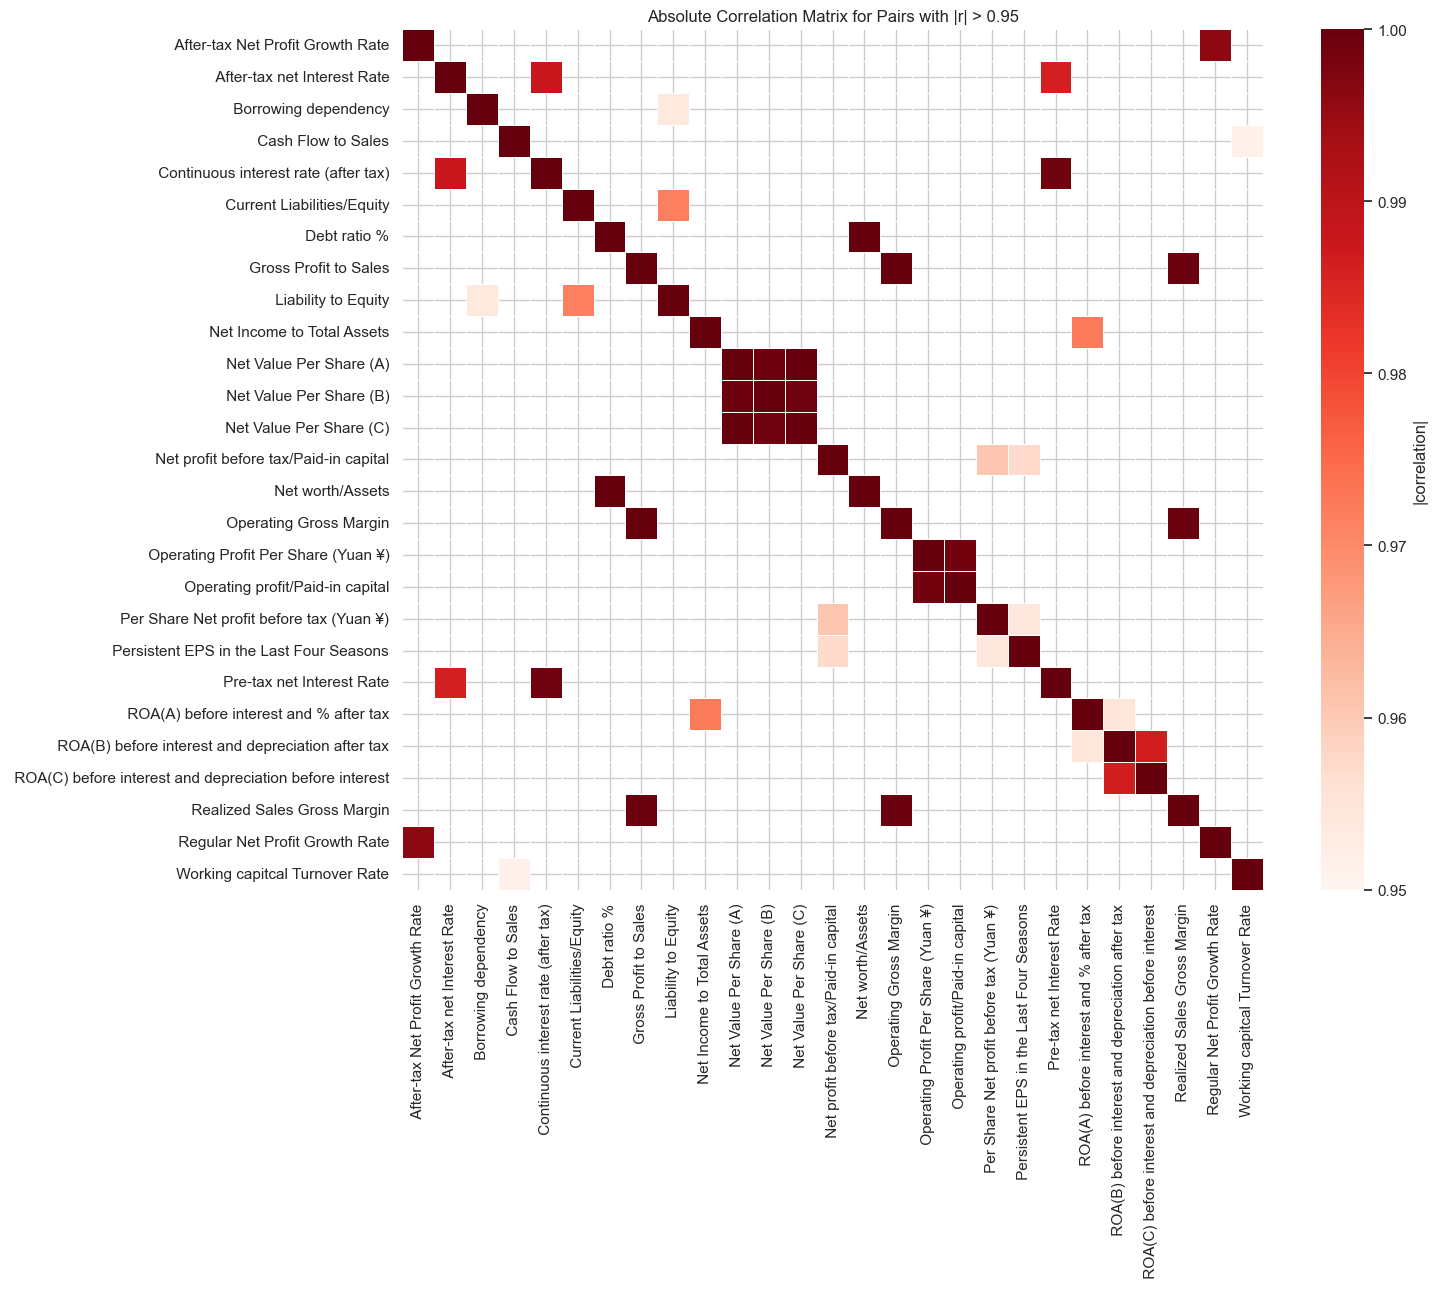

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

if manual_review_features:
    corr_manual = X_after_auto[manual_review_features].corr().abs()

    # маска: скрыть корреляции <= 0.95
    mask = corr_manual <= corr_threshold

    plt.figure(figsize=(16, 13))
    sns.heatmap(
        corr_manual,
        mask=mask,
        cmap='Reds',
        vmin=corr_threshold,
        vmax=1,
        square=True,
        linewidths=0.5,
        cbar_kws={'label': '|correlation|'}
    )
    plt.title(f'Absolute Correlation Matrix for Pairs with |r| > {corr_threshold}')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("No features in manual review pool.")

## Step C - Domain Tagging by Financial Blocks

In [9]:
manual_domain_map = {
    ' ROA(C) before interest and depreciation before interest': 'profitability',
    ' ROA(A) before interest and % after tax': 'profitability',
    ' ROA(B) before interest and depreciation after tax': 'profitability',
    ' Operating Gross Margin': 'profitability',
    ' Realized Sales Gross Margin': 'profitability',
    ' Operating Profit Rate': 'profitability',
    ' Pre-tax net Interest Rate': 'profitability',
    ' After-tax net Interest Rate': 'profitability',
    ' Non-industry income and expenditure/revenue': 'profitability',
    ' Operating profit/Paid-in capital': 'profitability',
    ' Net profit before tax/Paid-in capital': 'profitability',
    ' Net Income to Total Assets': 'profitability',
    ' Gross Profit to Sales': 'profitability',
    " Net Income to Stockholder's Equity": 'profitability',
    ' Total income/Total expense': 'profitability',
    ' Operating Profit Per Share (Yuan ¥)': 'profitability',
    ' Per Share Net profit before tax (Yuan ¥)': 'profitability',
    ' Current Ratio': 'liquidity',
    ' Quick Ratio': 'liquidity',
    ' Quick Assets/Current Liability': 'liquidity',
    ' Cash/Current Liability': 'liquidity',
    ' Current Liability to Current Assets': 'liquidity',
    ' No-credit Interval': 'liquidity',
    ' Inventory/Working Capital': 'liquidity',
    ' Interest-bearing debt interest rate': 'leverage_debt_burden',
    ' Total debt/Total net worth': 'leverage_debt_burden',
    ' Debt ratio %': 'leverage_debt_burden',
    ' Borrowing dependency': 'leverage_debt_burden',
    ' Contingent liabilities/Net worth': 'leverage_debt_burden',
    ' Current Liability to Assets': 'leverage_debt_burden',
    ' Inventory/Current Liability': 'leverage_debt_burden',
    ' Current Liabilities/Liability': 'leverage_debt_burden',
    ' Current Liabilities/Equity': 'leverage_debt_burden',
    ' Liability to Equity': 'leverage_debt_burden',
    ' Liability-Assets Flag': 'leverage_debt_burden',
    ' Cash flow rate': 'cash_flow_strength',
    ' Cash Flow Per Share': 'cash_flow_strength',
    ' Cash Reinvestment %': 'cash_flow_strength',
    ' Operating Funds to Liability': 'cash_flow_strength',
    ' Cash Flow to Sales': 'cash_flow_strength',
    ' Cash Flow to Total Assets': 'cash_flow_strength',
    ' Cash Flow to Liability': 'cash_flow_strength',
    ' CFO to Assets': 'cash_flow_strength',
    ' Cash Flow to Equity': 'cash_flow_strength',
    ' Net worth/Assets': 'solvency_capital_structure',
    ' Long-term fund suitability ratio (A)': 'solvency_capital_structure',
    ' Working Capital to Total Assets': 'solvency_capital_structure',
    ' Quick Assets/Total Assets': 'solvency_capital_structure',
    ' Current Assets/Total Assets': 'solvency_capital_structure',
    ' Cash/Total Assets': 'solvency_capital_structure',
    ' Working Capital/Equity': 'solvency_capital_structure',
    ' Long-term Liability to Current Assets': 'solvency_capital_structure',
    ' Retained Earnings to Total Assets': 'solvency_capital_structure',
    ' Fixed Assets to Assets': 'solvency_capital_structure',
    ' Equity to Long-term Liability': 'solvency_capital_structure',
    ' Total assets to GNP price': 'solvency_capital_structure',
    ' Equity to Liability': 'solvency_capital_structure',
    ' Net Value Per Share (A)': 'solvency_capital_structure',
    ' Net Value Per Share (B)': 'solvency_capital_structure',
    ' Net Value Per Share (C)': 'solvency_capital_structure',
    ' Inventory and accounts receivable/Net value': 'operating_efficiency_turnover',
    ' Total Asset Turnover': 'operating_efficiency_turnover',
    ' Accounts Receivable Turnover': 'operating_efficiency_turnover',
    ' Average Collection Days': 'operating_efficiency_turnover',
    ' Inventory Turnover Rate (times)': 'operating_efficiency_turnover',
    ' Fixed Assets Turnover Frequency': 'operating_efficiency_turnover',
    ' Net Worth Turnover Rate (times)': 'operating_efficiency_turnover',
    ' Revenue per person': 'operating_efficiency_turnover',
    ' Operating profit per person': 'operating_efficiency_turnover',
    ' Allocation rate per person': 'operating_efficiency_turnover',
    ' Current Asset Turnover Rate': 'operating_efficiency_turnover',
    ' Quick Asset Turnover Rate': 'operating_efficiency_turnover',
    ' Working capitcal Turnover Rate': 'operating_efficiency_turnover',
    ' Cash Turnover Rate': 'operating_efficiency_turnover',
    ' Revenue Per Share (Yuan ¥)': 'operating_efficiency_turnover',
    ' Persistent EPS in the Last Four Seasons': 'growth_stability',
    ' Realized Sales Gross Profit Growth Rate': 'growth_stability',
    ' Operating Profit Growth Rate': 'growth_stability',
    ' After-tax Net Profit Growth Rate': 'growth_stability',
    ' Regular Net Profit Growth Rate': 'growth_stability',
    ' Continuous Net Profit Growth Rate': 'growth_stability',
    ' Total Asset Growth Rate': 'growth_stability',
    ' Net Value Growth Rate': 'growth_stability',
    ' Total Asset Return Growth Rate Ratio': 'growth_stability',
    ' Continuous interest rate (after tax)': 'expense_coverage_quality',
    ' Operating Expense Rate': 'expense_coverage_quality',
    ' Research and development expense rate': 'expense_coverage_quality',
    ' Tax rate (A)': 'expense_coverage_quality',
    ' Interest Expense Ratio': 'expense_coverage_quality',
    ' Total expense/Assets': 'expense_coverage_quality',
    ' Degree of Financial Leverage (DFL)': 'expense_coverage_quality',
    ' Interest Coverage Ratio (Interest expense to EBIT)': 'expense_coverage_quality'
}

domain_map_df = pd.DataFrame({
    'feature': X_after_auto.columns,
    'domain_block': [manual_domain_map.get(col, 'unclassified') for col in X_after_auto.columns]
})
unclassified_features = domain_map_df.loc[domain_map_df['domain_block'] == 'unclassified', 'feature'].tolist()

display(domain_map_df.head(30))
display(domain_map_df['domain_block'].value_counts().rename_axis('domain_block').reset_index(name='count'))
print('unclassified feature count:', len(unclassified_features))
print('unclassified features     :', unclassified_features)

print_interpretation('Step C Result', [
    'Domain tagging now uses your manual financial taxonomy instead of keyword heuristics.',
    f'Unclassified features remaining after statistical cleanup: {len(unclassified_features)}.',
    'If this count is zero, the domain-balance step is grounded in an explicit and interpretable mapping.'
])

,feature,domain_block
0,ROA(C) before interest and depreciation befor...,profitability
1,ROA(A) before interest and % after tax,profitability
2,ROA(B) before interest and depreciation after...,profitability
3,Operating Gross Margin,profitability
4,Realized Sales Gross Margin,profitability
5,Operating Profit Rate,profitability
6,Pre-tax net Interest Rate,profitability
7,After-tax net Interest Rate,profitability
8,Non-industry income and expenditure/revenue,profitability
9,Continuous interest rate (after tax),expense_coverage_quality


,domain_block,count
0,profitability,17
1,solvency_capital_structure,16
2,operating_efficiency_turnover,15
3,leverage_debt_burden,11
4,cash_flow_strength,9
5,growth_stability,9
6,expense_coverage_quality,8
7,liquidity,7


unclassified feature count: 0
unclassified features     : []

[Step C Result]
- Domain tagging now uses your manual financial taxonomy instead of keyword heuristics.
- Unclassified features remaining after statistical cleanup: 0.
- If this count is zero, the domain-balance step is grounded in an explicit and interpretable mapping.


## Step D - Domain Balance Check

In [10]:
domain_balance = domain_map_df['domain_block'].value_counts().sort_values(ascending=False)
expected_blocks = [
    'profitability',
    'liquidity',
    'leverage_debt_burden',
    'cash_flow_strength',
    'solvency_capital_structure',
    'operating_efficiency_turnover',
    'growth_stability',
    'expense_coverage_quality'
]
missing_blocks = [block for block in expected_blocks if block not in domain_balance.index]
dominant_block = domain_balance.index[0] if not domain_balance.empty else None
dominant_count = int(domain_balance.iloc[0]) if not domain_balance.empty else 0

display(domain_balance)
print('missing financial blocks:', missing_blocks)
print('dominant block          :', dominant_block)
print('dominant block count    :', dominant_count)

print_interpretation('Step D Result', [
    f'Missing expected blocks: {missing_blocks}.',
    f'The current dominant block is {dominant_block} with {dominant_count} features.' if dominant_block else 'No dominant block detected.',
    'Now the balance check is based on your curated financial taxonomy rather than on a keyword heuristic.'
])

domain_block
profitability                    17
solvency_capital_structure       16
operating_efficiency_turnover    15
leverage_debt_burden             11
cash_flow_strength                9
growth_stability                  9
expense_coverage_quality          8
liquidity                         7
Name: count, dtype: int64

missing financial blocks: []
dominant block          : profitability
dominant block count    : 17

[Step D Result]
- Missing expected blocks: [].
- The current dominant block is profitability with 17 features.
- Now the balance check is based on your curated financial taxonomy rather than on a keyword heuristic.


## Step E - Manual Correction Layer

STEP E - FINAL FEATURE FILTERING SUMMARY
Total features before filtering : 92
Total features after filtering  : 46
Number of removed features      : 46

KEPT FEATURES:
 1.  ROA(A) before interest and % after tax
 2.  Operating Gross Margin
 3.  Operating Profit Rate
 4.  Operating profit/Paid-in capital
 5.  Net Income to Stockholder's Equity
 6.  Cash/Current Liability
 7.  Current Liability to Current Assets
 8.  Current Ratio
 9.  Quick Assets/Current Liability
10.  Quick Ratio
11.  No-credit Interval
12.  Inventory/Working Capital
13.  Borrowing dependency
14.  Contingent liabilities/Net worth
15.  Current Liability to Assets
16.  Current Liabilities/Liability
17.  Inventory/Current Liability
18.  Liability-Assets Flag
19.  Total debt/Total net worth
20.  CFO to Assets
21.  Cash Flow to Equity
22.  Cash Flow to Liability
23.  Cash Flow to Total Assets
24.  Cash Reinvestment %
25.  Cash flow rate
26.  Operating Funds to Liability
27.  Cash/Total Assets
28.  Current Assets/Total Asse

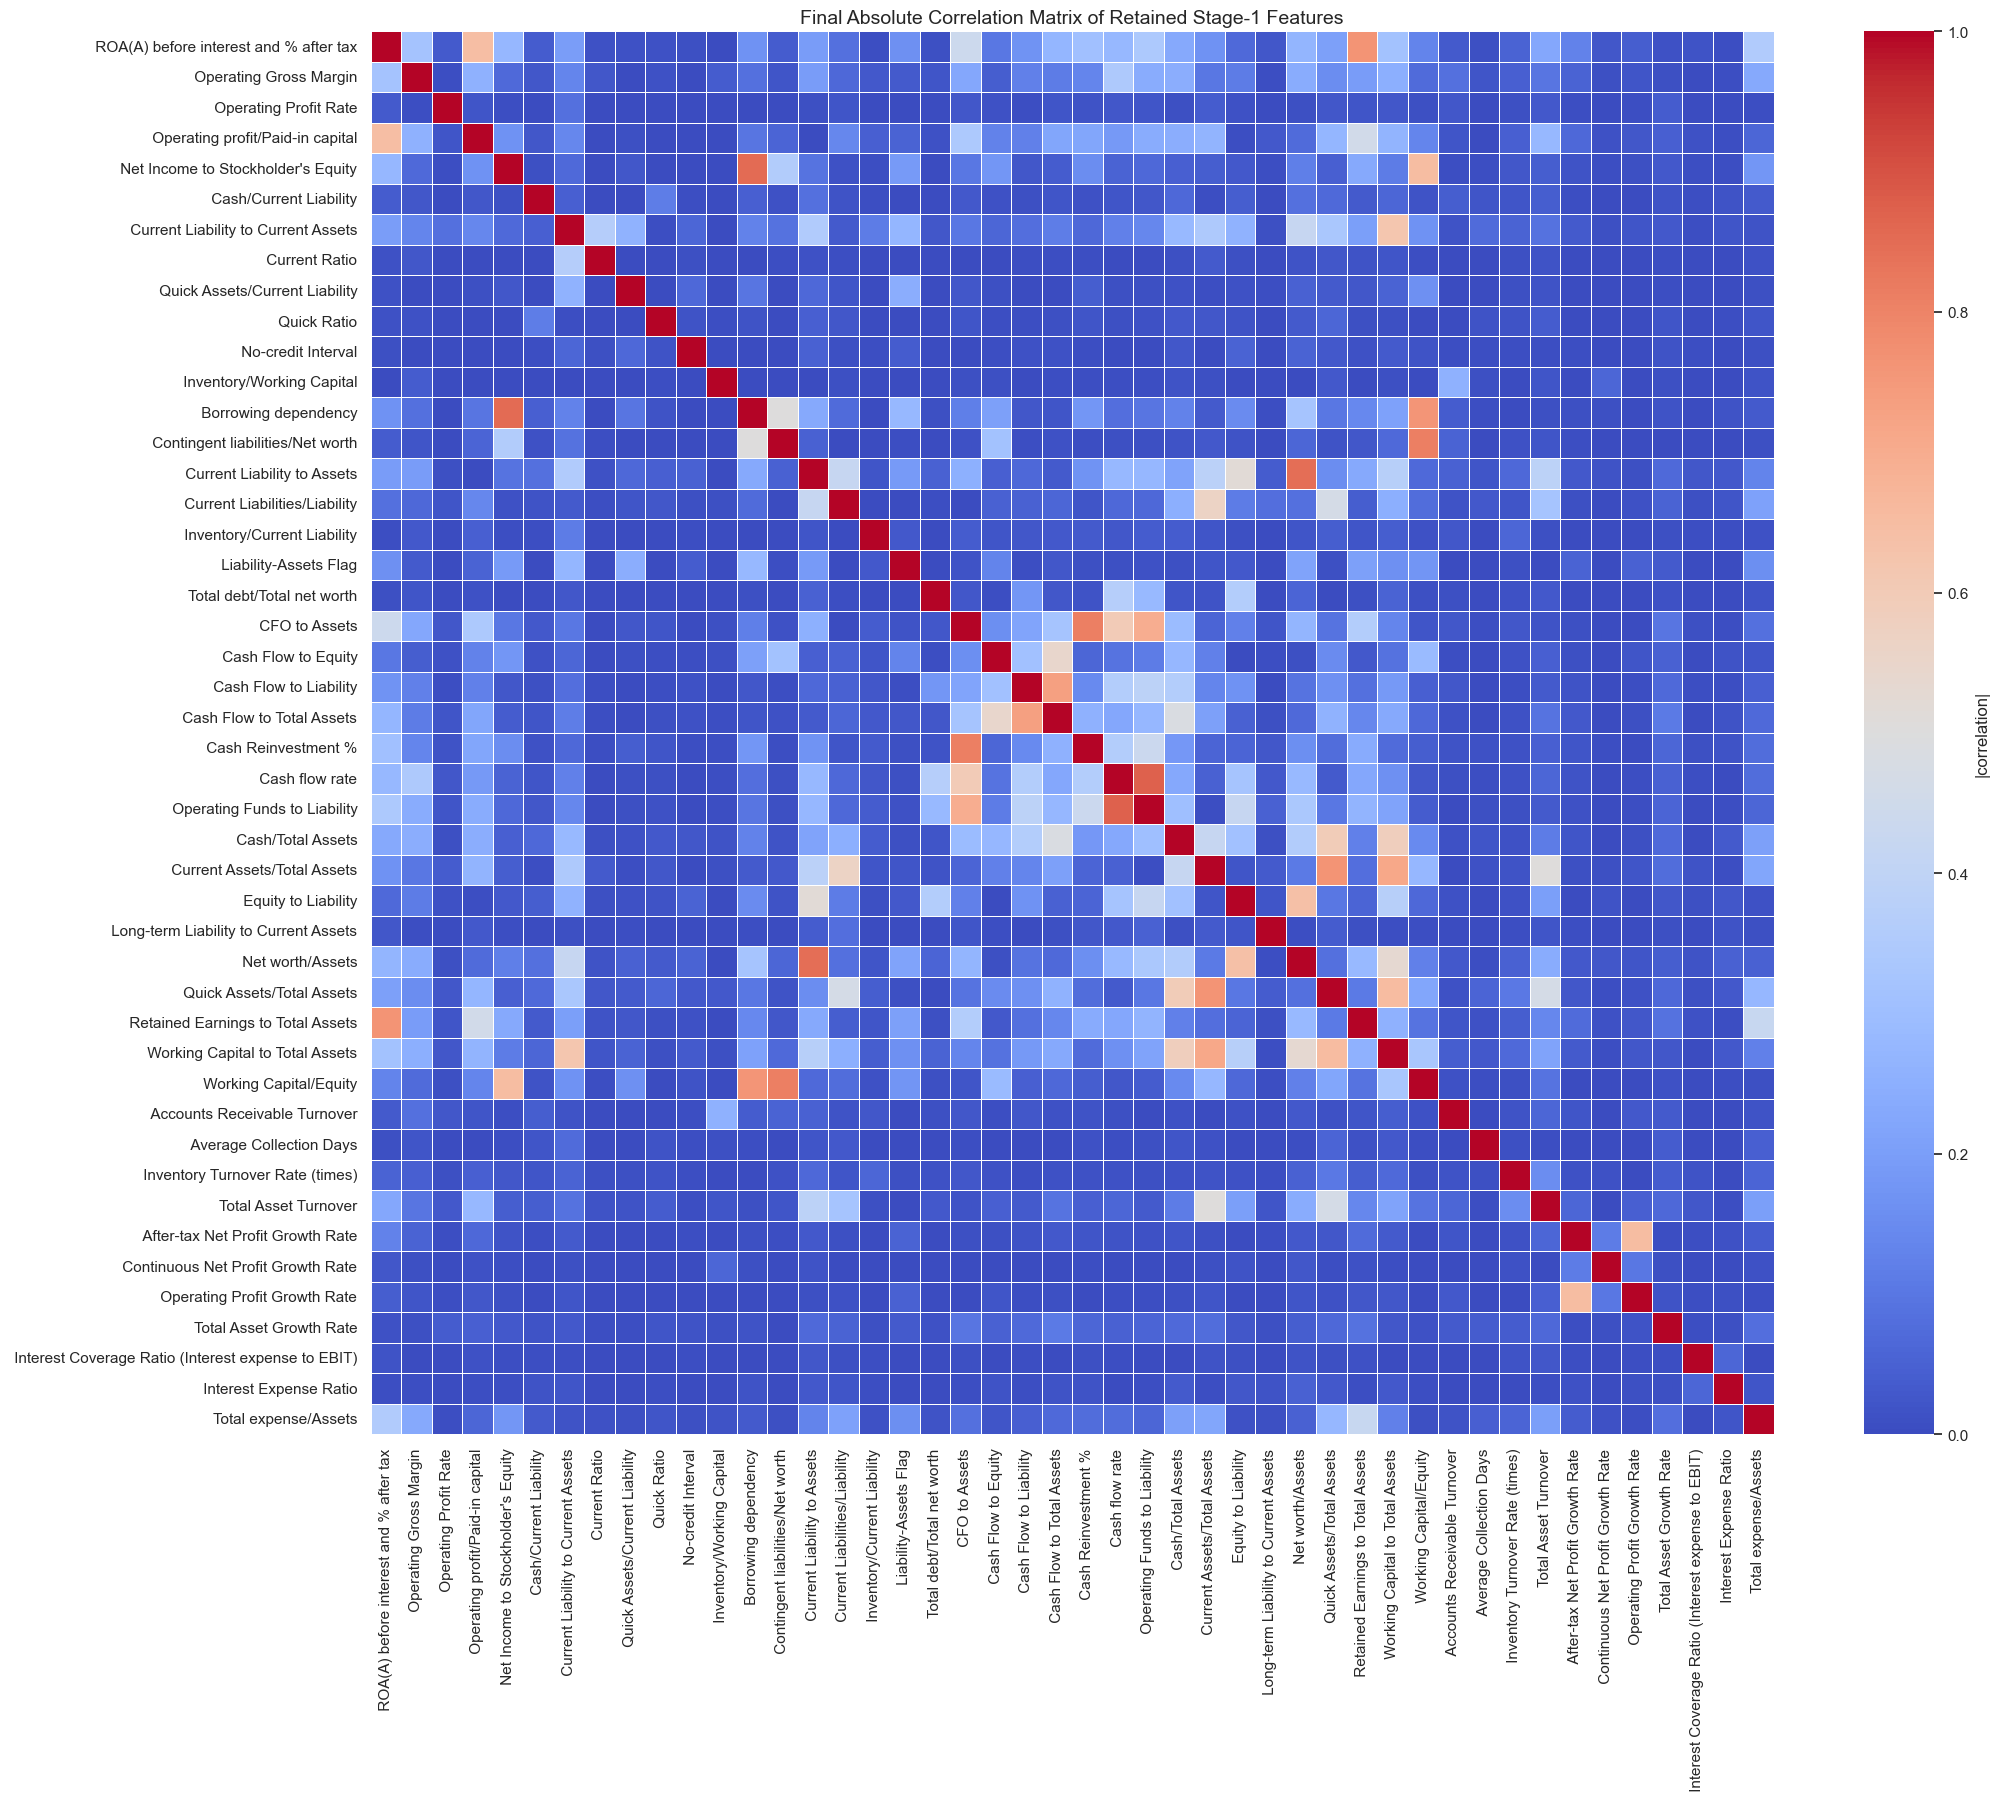

,feature_a,feature_b,abs_corr
1129,Cash flow rate,Operating Funds to Liability,0.874039
196,Net Income to Stockholder's Equity,Borrowing dependency,0.855247
674,Current Liability to Assets,Net worth/Assets,0.844324
897,CFO to Assets,Cash Reinvestment %,0.810474
632,Contingent liabilities/Net worth,Working Capital/Equity,0.809888
1273,Current Assets/Total Assets,Quick Assets/Total Assets,0.763936
32,ROA(A) before interest and % after tax,Retained Earnings to Total Assets,0.763735
586,Borrowing dependency,Working Capital/Equity,0.758967
988,Cash Flow to Liability,Cash Flow to Total Assets,0.730708
1275,Current Assets/Total Assets,Working Capital to Total Assets,0.713046



[Final Correlation Audit]
- The strongest remaining pairwise correlation is 0.874.
- This table checks whether the final retained set still contains near-duplicate features.


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ----------------------------
# Step E summary
# ----------------------------
final_stage1_features = [
    ' ROA(A) before interest and % after tax',
    ' Operating Gross Margin',
    ' Operating Profit Rate',
    ' Operating profit/Paid-in capital',
    " Net Income to Stockholder's Equity",
    ' Cash/Current Liability',
    ' Current Liability to Current Assets',
    ' Current Ratio',
    ' Quick Assets/Current Liability',
    ' Quick Ratio',
    ' No-credit Interval',
    ' Inventory/Working Capital',
    ' Borrowing dependency',
    ' Contingent liabilities/Net worth',
    ' Current Liability to Assets',
    ' Current Liabilities/Liability',
    ' Inventory/Current Liability',
    ' Liability-Assets Flag',
    ' Total debt/Total net worth',
    ' CFO to Assets',
    ' Cash Flow to Equity',
    ' Cash Flow to Liability',
    ' Cash Flow to Total Assets',
    ' Cash Reinvestment %',
    ' Cash flow rate',
    ' Operating Funds to Liability',
    ' Cash/Total Assets',
    ' Current Assets/Total Assets',
    ' Equity to Liability',
    ' Long-term Liability to Current Assets',
    ' Net worth/Assets',
    ' Quick Assets/Total Assets',
    ' Retained Earnings to Total Assets',
    ' Working Capital to Total Assets',
    ' Working Capital/Equity',
    ' Accounts Receivable Turnover',
    ' Average Collection Days',
    ' Inventory Turnover Rate (times)',
    ' Total Asset Turnover',
    ' After-tax Net Profit Growth Rate',
    ' Continuous Net Profit Growth Rate',
    ' Operating Profit Growth Rate',
    ' Total Asset Growth Rate',
    ' Interest Coverage Ratio (Interest expense to EBIT)',
    ' Interest Expense Ratio',
    ' Total expense/Assets'
]

manual_keep_features = final_stage1_features.copy()
manual_drop_features = sorted([col for col in X_after_auto.columns if col not in set(final_stage1_features)])
X_stage1 = X_after_auto[manual_keep_features].copy()

print('=' * 80)
print('STEP E - FINAL FEATURE FILTERING SUMMARY')
print('=' * 80)

print(f'Total features before filtering : {X_after_auto.shape[1]}')
print(f'Total features after filtering  : {X_stage1.shape[1]}')
print(f'Number of removed features      : {len(manual_drop_features)}')

print('\nKEPT FEATURES:')
for i, col in enumerate(manual_keep_features, 1):
    print(f'{i:2d}. {col}')

print('\nREMOVED FEATURES:')
for i, col in enumerate(manual_drop_features, 1):
    print(f'{i:2d}. {col}')

stage1_message = (
    'Still above the project ceiling; more reduction is needed.' if X_stage1.shape[1] > 50 else
    'Inside the preferred working range before PCA.' if 25 <= X_stage1.shape[1] <= 35 else
    'Within the hard ceiling, but still requires judgment on interpretability and balance.'
)

print_interpretation('Step E Result', [
    f'The manually corrected stage-1 feature set currently contains {X_stage1.shape[1]} features.',
    f'{len(manual_drop_features)} features were removed from the post-auto stage.',
    stage1_message,
    'This is the current stable feature set that should feed preprocessing candidate pipelines.'
])

# ----------------------------
# Correlation matrix of kept features
# ----------------------------
corr_stage1 = X_stage1.corr().abs()

plt.figure(figsize=(22, 18))
sns.heatmap(
    corr_stage1,
    cmap='coolwarm',
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.4,
    cbar_kws={'label': '|correlation|'}
)
plt.title('Final Absolute Correlation Matrix of Retained Stage-1 Features', fontsize=14)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


corr_stage1_upper = corr_stage1.where(np.triu(np.ones(corr_stage1.shape), k=1).astype(bool))

remaining_high_corr = (
    corr_stage1_upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_a', 'level_1': 'feature_b', 0: 'abs_corr'})
    .sort_values('abs_corr', ascending=False)
)

display(remaining_high_corr.head(30))

print_interpretation('Final Correlation Audit', [
    f'The strongest remaining pairwise correlation is {remaining_high_corr.iloc[0]["abs_corr"]:.3f}.',
    'This table checks whether the final retained set still contains near-duplicate features.'
])



## Soft Target Check on the Working Set

In [12]:
mi_scores = mutual_info_classif(X_stage1, y, random_state=SEED)
mi_df = pd.DataFrame({'feature': X_stage1.columns, 'mutual_info': mi_scores}).sort_values('mutual_info', ascending=False)
display(mi_df.head(20))

print_interpretation('Soft Target Diagnostic', [
    'This is a sanity check after statistical and domain filtering.',
    'We are verifying that the remaining feature set still has meaningful connection to bankruptcy behavior.',
    f'Top 10 features by mutual information are: {mi_df.head(10)["feature"].tolist()}.'
])

,feature,mutual_info
4,Net Income to Stockholder's Equity,0.042080
12,Borrowing dependency,0.041627
28,Equity to Liability,0.038314
30,Net worth/Assets,0.038116
0,ROA(A) before interest and % after tax,0.037474
44,Interest Expense Ratio,0.034479
43,Interest Coverage Ratio (Interest expense to ...,0.033552
32,Retained Earnings to Total Assets,0.033529
33,Working Capital to Total Assets,0.024160
3,Operating profit/Paid-in capital,0.023793



[Soft Target Diagnostic]
- This is a sanity check after statistical and domain filtering.
- We are verifying that the remaining feature set still has meaningful connection to bankruptcy behavior.
- Top 10 features by mutual information are: [" Net Income to Stockholder's Equity", ' Borrowing dependency', ' Equity to Liability', ' Net worth/Assets', ' ROA(A) before interest and % after tax', ' Interest Expense Ratio', ' Interest Coverage Ratio (Interest expense to EBIT)', ' Retained Earnings to Total Assets', ' Working Capital to Total Assets', ' Operating profit/Paid-in capital'].


## Preprocessing Candidates on the Working Set

In [13]:
from typing import Dict
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    RobustScaler,
    PowerTransformer,
    QuantileTransformer
)
from sklearn.decomposition import PCA

preprocessing_candidates: Dict[str, Pipeline] = {
    'standard_only': Pipeline([
        ('scaler', StandardScaler())
    ]),
    
    'robust_only': Pipeline([
        ('scaler', RobustScaler())
    ]),
    
    'power_standard': Pipeline([
        ('power', PowerTransformer()),
        ('scaler', StandardScaler())
    ]),
    
    'quantile_standard': Pipeline([
        ('quantile', QuantileTransformer(
            output_distribution='normal',
            n_quantiles=min(1000, X_stage1.shape[0]),
            random_state=SEED
        )),
        ('scaler', StandardScaler())
    ]),
    
    'standard_pca_12': Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=12, random_state=SEED))
    ]),
    
    'standard_pca_16': Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=16, random_state=SEED))
    ]),
    
    'robust_pca_12': Pipeline([
        ('scaler', RobustScaler()),
        ('pca', PCA(n_components=12, random_state=SEED))
    ]),
    
    'robust_pca_16': Pipeline([
        ('scaler', RobustScaler()),
        ('pca', PCA(n_components=16, random_state=SEED))
    ]),
    
    'power_pca_12': Pipeline([
        ('power', PowerTransformer()),
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=12, random_state=SEED))
    ])
}

candidate_shapes = []

for name, pipeline in preprocessing_candidates.items():
    transformed = pipeline.fit_transform(X_stage1)

    candidate_shapes.append({
        'candidate': name,
        'output_rows': transformed.shape[0],
        'output_cols': transformed.shape[1],
        'uses_pca': 'pca' in pipeline.named_steps,
        'pca_components': pipeline.named_steps['pca'].n_components if 'pca' in pipeline.named_steps else None,
        'uses_power': 'power' in pipeline.named_steps,
        'uses_quantile': 'quantile' in pipeline.named_steps,
        'scaler': type(pipeline.named_steps['scaler']).__name__ if 'scaler' in pipeline.named_steps else None
    })

candidate_shapes_df = pd.DataFrame(candidate_shapes).sort_values(
    by=['uses_pca', 'output_cols', 'candidate'],
    ascending=[True, True, True]
).reset_index(drop=True)

display(candidate_shapes_df)

print_interpretation('Pipeline Candidates', [
    'The candidate set now covers four preprocessing ideas: standard scaling, robust scaling, distribution-shape correction, and dimensionality reduction.',
    'Scaler-only pipelines preserve the full feature space, while PCA pipelines test whether clustering becomes clearer in a compressed representation.',
    'The added power-plus-PCA path checks whether reducing skewness before compression produces a cleaner geometry for clustering.',
    'The quantile-based candidate tests a stronger normalization strategy for heavily skewed financial ratios.',
    'This candidate library is broad enough for disciplined clustering experiments without becoming an unmanageable grid.'
])

,candidate,output_rows,output_cols,uses_pca,pca_components,uses_power,uses_quantile,scaler
0,power_standard,5807,46,False,NaN,True,False,StandardScaler
1,quantile_standard,5807,46,False,NaN,False,True,StandardScaler
2,robust_only,5807,46,False,NaN,False,False,RobustScaler
3,standard_only,5807,46,False,NaN,False,False,StandardScaler
4,power_pca_12,5807,12,True,12.0,True,False,StandardScaler
5,robust_pca_12,5807,12,True,12.0,False,False,RobustScaler
6,standard_pca_12,5807,12,True,12.0,False,False,StandardScaler
7,robust_pca_16,5807,16,True,16.0,False,False,RobustScaler
8,standard_pca_16,5807,16,True,16.0,False,False,StandardScaler



[Pipeline Candidates]
- The candidate set now covers four preprocessing ideas: standard scaling, robust scaling, distribution-shape correction, and dimensionality reduction.
- Scaler-only pipelines preserve the full feature space, while PCA pipelines test whether clustering becomes clearer in a compressed representation.
- The added power-plus-PCA path checks whether reducing skewness before compression produces a cleaner geometry for clustering.
- The quantile-based candidate tests a stronger normalization strategy for heavily skewed financial ratios.
- This candidate library is broad enough for disciplined clustering experiments without becoming an unmanageable grid.


## Persistence Skeleton

In [14]:
stage1_artifact = {
    'safe_remove_features': safe_remove_features,
    'review_features': review_features,
    'manual_review_features': manual_review_features,
    'manual_keep_features': manual_keep_features,
    'manual_drop_features': manual_drop_features,
    'selected_feature_cols': list(X_stage1.columns),
    'selected_feature_count': X_stage1.shape[1],
    'domain_map': manual_domain_map,
    'corr_threshold': corr_threshold,
    'candidate_names': list(preprocessing_candidates.keys()),
    'seed': SEED
}

artifact_path = MODELS_DIR / 'stage1_preprocessing_skeleton.joblib'
print('planned artifact path:', artifact_path)
print('stage1_artifact summary:')
print('  saved keys                  :', list(stage1_artifact.keys()))
print('  safe auto-removed features  :', len(stage1_artifact['safe_remove_features']))
print('  review features             :', len(stage1_artifact['review_features']))
print('  correlation-review features :', len(stage1_artifact['manual_review_features']))
print('  selected feature count      :', stage1_artifact['selected_feature_count'])
print('  manually dropped features   :', len(stage1_artifact['manual_drop_features']))
print('  domain map size             :', len(stage1_artifact['domain_map']))
print('  preprocessing candidates    :', stage1_artifact['candidate_names'])
print('\nselected features:')
for i, feature in enumerate(stage1_artifact['selected_feature_cols'], 1):
    print(f'  {i:2d}. {feature}')
print('\nmanual drop features:')
for i, feature in enumerate(stage1_artifact['manual_drop_features'], 1):
    print(f'  {i:2d}. {feature}')
print('\nsafe auto-remove features:')
for i, feature in enumerate(stage1_artifact['safe_remove_features'], 1):
    print(f'  {i:2d}. {feature}')
print('\nstep A_A review features:')
for i, feature in enumerate(stage1_artifact['review_features'], 1):
    print(f'  {i:2d}. {feature}')
print('\nstep B manual review features:')
for i, feature in enumerate(stage1_artifact['manual_review_features'], 1):
    print(f'  {i:2d}. {feature}')

print_interpretation('Persistence Plan', [
    'The stage-1 artifact skeleton now uses the current Step A_A and Step E variable names.',
    'It captures safe auto-removals, manual review pools, final selected columns, and the explicit domain map.',
    'The cell now prints a full persistence report before the interpretation block so the saved artifact contents are visible directly in notebook output.',
    'This makes the taxonomy reproducible instead of hiding it in notebook text.',
    'Once the stage-1 decisions are stable, this structure can be serialized with joblib.'
])

planned artifact path: S:\OneDriveMoleff\OneDrive - moleff.com\Documents\___STEVENS\CS_Program\CS559\HWs\finalProject\models\stage1_preprocessing_skeleton.joblib
stage1_artifact summary:
  saved keys                  : ['safe_remove_features', 'review_features', 'manual_review_features', 'manual_keep_features', 'manual_drop_features', 'selected_feature_cols', 'selected_feature_count', 'domain_map', 'corr_threshold', 'candidate_names', 'seed']
  safe auto-removed features  : 3
  review features             : 1
  correlation-review features : 27
  selected feature count      : 46
  manually dropped features   : 46
  domain map size             : 92
  preprocessing candidates    : ['standard_only', 'robust_only', 'power_standard', 'quantile_standard', 'standard_pca_12', 'standard_pca_16', 'robust_pca_12', 'robust_pca_16', 'power_pca_12']

selected features:
   1.  ROA(A) before interest and % after tax
   2.  Operating Gross Margin
   3.  Operating Profit Rate
   4.  Operating profit/Paid

## First Clustering Baseline Sweep

In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np
import pandas as pd

# automatically include every preprocessing candidate defined earlier
kmeans_preprocessing_names = list(preprocessing_candidates.keys())
kmeans_k_values = [4, 5, 6, 7]

# =========================
# Practical validity thresholds
# =========================
MIN_CLUSTER_SHARE = 0.05
MAX_CLUSTER_SHARE = 0.70
MIN_CLUSTER_SIZE_ABS = 80
MIN_BANKRUPT_IN_NONCONSTANT_CLUSTER = 5

kmeans_sweep_rows = []
kmeans_cluster_detail_rows = []

for preprocessing_name in kmeans_preprocessing_names:
    transformed = preprocessing_candidates[preprocessing_name].fit_transform(X_stage1)

    for k in kmeans_k_values:
        kmeans = KMeans(n_clusters=k, n_init=20, random_state=SEED)
        labels = pd.Series(
            kmeans.fit_predict(transformed),
            index=X_stage1.index,
            name='cluster_id'
        )

        cluster_sizes = labels.value_counts().sort_index()
        cluster_shares = cluster_sizes / len(labels)

        # Unsupervised metrics
        silhouette = silhouette_score(transformed, labels)
        davies_bouldin = davies_bouldin_score(transformed, labels)
        calinski_harabasz = calinski_harabasz_score(transformed, labels)

        # Target diagnostics by cluster
        total_count_by_cluster = y.groupby(labels).size().sort_index()
        bankrupt_count_by_cluster = y.groupby(labels).sum().sort_index()
        non_bankrupt_count_by_cluster = total_count_by_cluster - bankrupt_count_by_cluster
        bankruptcy_rate_by_cluster = y.groupby(labels).mean().sort_index()

        # Constant / mixed cluster detection
        all_zero_clusters = bankrupt_count_by_cluster[bankrupt_count_by_cluster == 0].index.tolist()
        all_one_clusters = bankrupt_count_by_cluster[
            bankrupt_count_by_cluster == total_count_by_cluster
        ].index.tolist()
        constant_clusters = sorted(set(all_zero_clusters + all_one_clusters))
        nonconstant_clusters = [cid for cid in cluster_sizes.index if cid not in constant_clusters]

        # Practical validity checks
        has_too_small_cluster = bool((cluster_sizes < MIN_CLUSTER_SIZE_ABS).any())
        has_too_small_share = bool((cluster_shares < MIN_CLUSTER_SHARE).any())
        has_too_large_cluster = bool((cluster_shares > MAX_CLUSTER_SHARE).any())

        if len(nonconstant_clusters) > 0:
            min_bankrupt_nonconstant = int(bankrupt_count_by_cluster.loc[nonconstant_clusters].min())
            has_weak_nonconstant_cluster = bool(
                (bankrupt_count_by_cluster.loc[nonconstant_clusters] < MIN_BANKRUPT_IN_NONCONSTANT_CLUSTER).any()
            )
        else:
            min_bankrupt_nonconstant = 0
            has_weak_nonconstant_cluster = True

        num_constant_clusters = len(constant_clusters)
        num_nonconstant_clusters = len(nonconstant_clusters)

        is_practically_valid = bool(
            (not has_too_small_cluster) and
            (not has_too_small_share) and
            (not has_too_large_cluster) and
            (num_nonconstant_clusters >= 2) and
            (not has_weak_nonconstant_cluster)
        )

        is_relaxed_valid = bool(
            (not has_too_large_cluster) and
            (num_nonconstant_clusters >= 2)
        )

        # Failure reasons
        failure_reasons = []
        if has_too_small_cluster:
            failure_reasons.append('too_small_cluster')
        if has_too_small_share:
            failure_reasons.append('too_small_share')
        if has_too_large_cluster:
            failure_reasons.append('too_large_cluster')
        if has_weak_nonconstant_cluster:
            failure_reasons.append('weak_nonconstant_cluster')
        if num_nonconstant_clusters < 2:
            failure_reasons.append('too_few_nonconstant_clusters')

        if len(failure_reasons) == 0:
            failure_reason_text = 'valid'
        else:
            failure_reason_text = ', '.join(failure_reasons)

        # Save sweep-level diagnostics
        kmeans_sweep_rows.append({
            'preprocessing': preprocessing_name,
            'algorithm': 'kmeans',
            'k': k,

            # Unsupervised metrics
            'silhouette': float(silhouette),
            'davies_bouldin': float(davies_bouldin),
            'calinski_harabasz': float(calinski_harabasz),

            # Structure / practicality
            'min_cluster_size': int(cluster_sizes.min()),
            'max_cluster_size': int(cluster_sizes.max()),
            'smallest_cluster_share': float(cluster_shares.min()),
            'largest_cluster_share': float(cluster_shares.max()),
            'num_constant_clusters': int(num_constant_clusters),
            'num_nonconstant_clusters': int(num_nonconstant_clusters),
            'all_zero_cluster_ids': all_zero_clusters,
            'all_one_cluster_ids': all_one_clusters,
            'min_bankrupt_nonconstant_cluster': int(min_bankrupt_nonconstant),
            'has_too_small_cluster': has_too_small_cluster,
            'has_too_small_share': has_too_small_share,
            'has_too_large_cluster': has_too_large_cluster,
            'has_weak_nonconstant_cluster': has_weak_nonconstant_cluster,
            'is_practically_valid': is_practically_valid,
            'is_relaxed_valid': is_relaxed_valid,
            'failure_reasons': failure_reason_text,

            # Target diagnostics
            'bankruptcy_rate_std': float(bankruptcy_rate_by_cluster.std(ddof=0)),
            'bankruptcy_rate_range': float(bankruptcy_rate_by_cluster.max() - bankruptcy_rate_by_cluster.min()),
            'overall_bankrupt_count': int(y.sum())
        })

        # Save cluster-level diagnostics
        for cluster_id in cluster_sizes.index:
            cluster_size = int(cluster_sizes.loc[cluster_id])
            cluster_share = float(cluster_shares.loc[cluster_id])
            bankrupt_count = int(bankrupt_count_by_cluster.loc[cluster_id])
            non_bankrupt_count = int(non_bankrupt_count_by_cluster.loc[cluster_id])
            bankruptcy_rate = float(bankruptcy_rate_by_cluster.loc[cluster_id])

            if bankrupt_count == 0:
                cluster_type = 'constant_zero'
            elif bankrupt_count == cluster_size:
                cluster_type = 'constant_one'
            else:
                cluster_type = 'mixed'

            kmeans_cluster_detail_rows.append({
                'preprocessing': preprocessing_name,
                'algorithm': 'kmeans',
                'k': k,
                'cluster_id': int(cluster_id),
                'cluster_size': cluster_size,
                'cluster_share': cluster_share,
                'bankrupt_count': bankrupt_count,
                'non_bankrupt_count': non_bankrupt_count,
                'bankruptcy_rate': bankruptcy_rate,
                'cluster_type': cluster_type,
                'is_small_cluster': cluster_size < MIN_CLUSTER_SIZE_ABS,
                'is_small_share_cluster': cluster_share < MIN_CLUSTER_SHARE,
                'is_large_share_cluster': cluster_share > MAX_CLUSTER_SHARE,
                'is_weak_nonconstant_cluster': (
                    (cluster_type == 'mixed') and
                    (bankrupt_count < MIN_BANKRUPT_IN_NONCONSTANT_CLUSTER)
                )
            })

# =========================
# DataFrames
# =========================
kmeans_sweep_df = pd.DataFrame(kmeans_sweep_rows)
kmeans_cluster_details_df = pd.DataFrame(kmeans_cluster_detail_rows)

# =========================
# Main ranked outputs
# =========================
kmeans_unsupervised_ranked_df = (
    kmeans_sweep_df.loc[kmeans_sweep_df['is_practically_valid']].copy()
    .sort_values(
        ['silhouette', 'davies_bouldin', 'calinski_harabasz'],
        ascending=[False, True, False]
    )
    .reset_index(drop=True)
)

kmeans_project_ranked_df = (
    kmeans_sweep_df.loc[kmeans_sweep_df['is_practically_valid']].copy()
    .sort_values(
        ['bankruptcy_rate_range', 'bankruptcy_rate_std', 'silhouette'],
        ascending=[False, False, False]
    )
    .reset_index(drop=True)
)

kmeans_relaxed_ranked_df = (
    kmeans_sweep_df.loc[kmeans_sweep_df['is_relaxed_valid']].copy()
    .sort_values(
        ['silhouette', 'bankruptcy_rate_range', 'davies_bouldin'],
        ascending=[False, False, True]
    )
    .reset_index(drop=True)
)

kmeans_full_audit_df = (
    kmeans_sweep_df.sort_values(
        ['is_practically_valid', 'is_relaxed_valid', 'silhouette', 'bankruptcy_rate_range'],
        ascending=[False, False, False, False]
    )
    .reset_index(drop=True)
)

# =========================
# Shortlist view
# =========================
kmeans_shortlist_df = (
    kmeans_full_audit_df[
        [
            'preprocessing', 'k',
            'is_practically_valid', 'is_relaxed_valid',
            'failure_reasons',
            'silhouette', 'davies_bouldin', 'calinski_harabasz',
            'min_cluster_size', 'max_cluster_size',
            'smallest_cluster_share', 'largest_cluster_share',
            'num_constant_clusters', 'num_nonconstant_clusters',
            'min_bankrupt_nonconstant_cluster',
            'bankruptcy_rate_std', 'bankruptcy_rate_range',
            'all_zero_cluster_ids', 'all_one_cluster_ids'
        ]
    ]
    .copy()
)

# =========================
# Per-solution cluster pattern summary
# =========================
cluster_pattern_summary_df = (
    kmeans_cluster_details_df.groupby(['preprocessing', 'k'])
    .agg(
        n_clusters=('cluster_id', 'count'),
        min_cluster_size=('cluster_size', 'min'),
        max_cluster_size=('cluster_size', 'max'),
        median_cluster_size=('cluster_size', 'median'),
        num_constant_zero=('cluster_type', lambda s: (s == 'constant_zero').sum()),
        num_constant_one=('cluster_type', lambda s: (s == 'constant_one').sum()),
        num_mixed=('cluster_type', lambda s: (s == 'mixed').sum()),
        num_small_abs=('is_small_cluster', 'sum'),
        num_small_share=('is_small_share_cluster', 'sum'),
        num_large_share=('is_large_share_cluster', 'sum'),
        num_weak_nonconstant=('is_weak_nonconstant_cluster', 'sum'),
        min_bankruptcy_rate=('bankruptcy_rate', 'min'),
        max_bankruptcy_rate=('bankruptcy_rate', 'max')
    )
    .reset_index()
)

cluster_pattern_summary_df = (
    cluster_pattern_summary_df.merge(
        kmeans_sweep_df[
            [
                'preprocessing', 'k',
                'is_practically_valid', 'is_relaxed_valid',
                'failure_reasons',
                'silhouette', 'davies_bouldin', 'calinski_harabasz',
                'bankruptcy_rate_std', 'bankruptcy_rate_range'
            ]
        ],
        on=['preprocessing', 'k'],
        how='left'
    )
    .sort_values(
        ['is_practically_valid', 'is_relaxed_valid', 'max_cluster_size', 'min_cluster_size'],
        ascending=[False, False, False, True]
    )
    .reset_index(drop=True)
)

# =========================
# Detailed diagnostic table
# =========================
diagnostic_df = (
    kmeans_sweep_df.copy()
    .sort_values(
        ['is_practically_valid', 'is_relaxed_valid', 'largest_cluster_share', 'smallest_cluster_share'],
        ascending=[False, False, False, True]
    )
    .reset_index(drop=True)
)

# Safe displays
print('====================')
print('KMEANS SHORTLIST')
print('====================')
display(kmeans_shortlist_df)

print('====================')
print('STRICT VALID SOLUTIONS')
print('====================')
if len(kmeans_unsupervised_ranked_df) == 0:
    print('No strictly valid KMeans solutions found under current practical thresholds.')
else:
    display(kmeans_unsupervised_ranked_df)

print('====================')
print('STRICT PROJECT-RANKED SOLUTIONS')
print('====================')
if len(kmeans_project_ranked_df) == 0:
    print('No strictly valid KMeans solutions found for project-ranked view.')
else:
    display(kmeans_project_ranked_df)

print('====================')
print('RELAXED VALID SOLUTIONS')
print('====================')
if len(kmeans_relaxed_ranked_df) == 0:
    print('No relaxed-valid KMeans solutions found either.')
else:
    display(kmeans_relaxed_ranked_df)

print('====================')
print('FULL DIAGNOSTIC TABLE')
print('====================')
display(
    diagnostic_df[
        [
            'preprocessing', 'k',
            'is_practically_valid', 'is_relaxed_valid',
            'failure_reasons',
            'silhouette', 'davies_bouldin', 'calinski_harabasz',
            'min_cluster_size', 'max_cluster_size',
            'smallest_cluster_share', 'largest_cluster_share',
            'num_constant_clusters', 'num_nonconstant_clusters',
            'min_bankrupt_nonconstant_cluster',
            'has_too_small_cluster',
            'has_too_small_share',
            'has_too_large_cluster',
            'has_weak_nonconstant_cluster',
            'bankruptcy_rate_std', 'bankruptcy_rate_range',
            'all_zero_cluster_ids', 'all_one_cluster_ids'
        ]
    ]
)

print('====================')
print('CLUSTER PATTERN SUMMARY')
print('====================')
display(cluster_pattern_summary_df)

print('====================')
print('FULL CLUSTER DETAILS')
print('====================')
display(
    kmeans_cluster_details_df.sort_values(
        ['preprocessing', 'k', 'cluster_size'],
        ascending=[True, True, False]
    ).reset_index(drop=True)
)

# =========================
# Aggregate failure summaries
# =========================
invalid_df = diagnostic_df.loc[~diagnostic_df['is_practically_valid']].copy()

print('====================')
print('SUMMARY COUNTS')
print('====================')
print('Valid solutions count:', int(diagnostic_df['is_practically_valid'].sum()))
print('Relaxed-valid solutions count:', int(diagnostic_df['is_relaxed_valid'].sum()))
print('Total checked solutions:', int(len(diagnostic_df)))

print('\nRule failure counts:')
print('has_too_small_cluster        =', int(diagnostic_df['has_too_small_cluster'].sum()))
print('has_too_small_share          =', int(diagnostic_df['has_too_small_share'].sum()))
print('has_too_large_cluster        =', int(diagnostic_df['has_too_large_cluster'].sum()))
print('has_weak_nonconstant_cluster =', int(diagnostic_df['has_weak_nonconstant_cluster'].sum()))
print('num_nonconstant_clusters < 2 =', int((diagnostic_df['num_nonconstant_clusters'] < 2).sum()))

print('\nFailure reason combinations:')
if len(invalid_df) == 0:
    print('No invalid solutions.')
else:
    display(invalid_df['failure_reasons'].value_counts().rename_axis('failure_reason_combo').reset_index(name='count'))

# =========================
# Human-readable diagnosis
# =========================
print('====================')
print('HUMAN-READABLE DIAGNOSIS')
print('====================')
for _, row in diagnostic_df.iterrows():
    print('-' * 120)
    print(f"preprocessing={row['preprocessing']}, k={row['k']}")
    print(f"strict_valid={row['is_practically_valid']}, relaxed_valid={row['is_relaxed_valid']}")
    print(f"failure_reasons={row['failure_reasons']}")
    print(
        f"silhouette={row['silhouette']:.6f}, "
        f"davies_bouldin={row['davies_bouldin']:.6f}, "
        f"calinski_harabasz={row['calinski_harabasz']:.3f}"
    )
    print(
        f"min_cluster_size={row['min_cluster_size']}, "
        f"max_cluster_size={row['max_cluster_size']}"
    )
    print(
        f"smallest_cluster_share={row['smallest_cluster_share']:.6f}, "
        f"largest_cluster_share={row['largest_cluster_share']:.6f}"
    )
    print(
        f"num_constant_clusters={row['num_constant_clusters']}, "
        f"num_nonconstant_clusters={row['num_nonconstant_clusters']}"
    )
    print(
        f"all_zero_cluster_ids={row['all_zero_cluster_ids']}, "
        f"all_one_cluster_ids={row['all_one_cluster_ids']}"
    )
    print(
        f"min_bankrupt_nonconstant_cluster={row['min_bankrupt_nonconstant_cluster']}, "
        f"bankruptcy_rate_std={row['bankruptcy_rate_std']:.6f}, "
        f"bankruptcy_rate_range={row['bankruptcy_rate_range']:.6f}"
    )

print_interpretation('KMeans Sweep With Full Diagnostics', [
    f'Compared {len(kmeans_preprocessing_names)} preprocessing variants across k values {kmeans_k_values}.',
    'The block now separates strict-valid, relaxed-valid, and fully invalid solutions.',
    'Failure reasons are reported explicitly for each preprocessing and k combination.',
    'Cluster-level diagnostics are displayed so degenerate solutions can be identified directly.',
    'If strict-valid tables are empty, the diagnostic tables show whether the cause is tiny clusters, dominant clusters, weak mixed clusters, or too few usable mixed clusters.'
])

KMEANS SHORTLIST


,preprocessing,k,is_practically_valid,is_relaxed_valid,failure_reasons,silhouette,davies_bouldin,calinski_harabasz,min_cluster_size,max_cluster_size,smallest_cluster_share,largest_cluster_share,num_constant_clusters,num_nonconstant_clusters,min_bankrupt_nonconstant_cluster,bankruptcy_rate_std,bankruptcy_rate_range,all_zero_cluster_ids,all_one_cluster_ids
0,quantile_standard,4,True,True,valid,0.125657,2.202640,766.433925,872,2432,0.150164,0.418805,1,3,8,0.065961,0.160550,[2],[]
1,quantile_standard,5,True,True,valid,0.105253,2.307086,677.014800,851,1527,0.146547,0.262958,1,4,7,0.062479,0.165687,[3],[]
2,standard_pca_12,4,False,True,"too_small_cluster, too_small_share, weak_nonco...",0.198662,1.426835,723.274187,3,2859,0.000517,0.492337,1,3,1,0.420497,0.999141,[],[3]
3,standard_pca_12,5,False,True,"too_small_cluster, too_small_share, weak_nonco...",0.197650,1.365894,677.633759,2,2826,0.000344,0.486654,1,4,1,0.393263,0.999127,[],[4]
4,standard_pca_16,7,False,True,"too_small_cluster, too_small_share, weak_nonco...",0.179257,0.960560,474.848668,1,2849,0.000172,0.490615,4,3,1,0.339332,1.000000,"[2, 5, 6]",[4]
5,standard_pca_16,6,False,True,"too_small_cluster, too_small_share, weak_nonco...",0.177126,1.419477,525.221952,3,2783,0.000517,0.479249,2,4,1,0.368901,1.000000,[1],[3]
6,standard_pca_12,6,False,True,"too_small_cluster, too_small_share, weak_nonco...",0.176814,1.290696,639.119908,1,2682,0.000172,0.461856,2,4,1,0.361247,1.000000,[4],[2]
7,standard_pca_16,4,False,True,"too_small_cluster, too_small_share, weak_nonco...",0.175991,1.565906,595.254198,3,2842,0.000517,0.489409,1,3,1,0.420547,0.999135,[],[2]
8,standard_pca_12,7,False,True,"too_small_cluster, too_small_share, weak_nonco...",0.172691,1.229013,636.930975,1,2585,0.000172,0.445152,2,5,1,0.366791,1.000000,[5],[4]
9,power_pca_12,4,False,True,"too_small_cluster, too_small_share, weak_nonco...",0.164589,1.537409,790.100401,7,2372,0.001205,0.408473,0,4,2,0.297090,0.712877,[],[]


STRICT VALID SOLUTIONS


,preprocessing,algorithm,k,silhouette,davies_bouldin,calinski_harabasz,min_cluster_size,max_cluster_size,smallest_cluster_share,largest_cluster_share,num_constant_clusters,num_nonconstant_clusters,all_zero_cluster_ids,all_one_cluster_ids,min_bankrupt_nonconstant_cluster,has_too_small_cluster,has_too_small_share,has_too_large_cluster,has_weak_nonconstant_cluster,is_practically_valid,is_relaxed_valid,failure_reasons,bankruptcy_rate_std,bankruptcy_rate_range,overall_bankrupt_count
0,quantile_standard,kmeans,4,0.125657,2.202640,766.433925,872,2432,0.150164,0.418805,1,3,[2],[],8,False,False,False,False,True,True,valid,0.065961,0.160550,198
1,quantile_standard,kmeans,5,0.105253,2.307086,677.014800,851,1527,0.146547,0.262958,1,4,[3],[],7,False,False,False,False,True,True,valid,0.062479,0.165687,198


STRICT PROJECT-RANKED SOLUTIONS


...

FULL CLUSTER DETAILS


,preprocessing,algorithm,k,cluster_id,cluster_size,cluster_share,bankrupt_count,non_bankrupt_count,bankruptcy_rate,cluster_type,is_small_cluster,is_small_share_cluster,is_large_share_cluster,is_weak_nonconstant_cluster
0,power_pca_12,kmeans,4,2,2372,0.408473,111,2261,0.046796,mixed,False,False,False,False
1,power_pca_12,kmeans,4,0,2008,0.345790,80,1928,0.039841,mixed,False,False,False,False
2,power_pca_12,kmeans,4,1,1420,0.244532,2,1418,0.001408,mixed,False,False,False,True
3,power_pca_12,kmeans,4,3,7,0.001205,5,2,0.714286,mixed,True,True,False,False
4,power_pca_12,kmeans,5,1,1911,0.329086,12,1899,0.006279,mixed,False,False,False,False
5,power_pca_12,kmeans,5,4,1699,0.292578,12,1687,0.007063,mixed,False,False,False,False
6,power_pca_12,kmeans,5,3,1222,0.210436,168,1054,0.137480,mixed,False,False,False,False
7,power_pca_12,kmeans,5,2,968,0.166695,1,967,0.001033,mixed,False,False,False,True
8,power_pca_12,kmeans,5,0,7,0.001205,5,2,0.714286,mixed,True,True,False,False
9,power_pca_12,kmeans,6,0,1868,0.321681,12,1856,0.006424,mixed,False,False,False,False


SUMMARY COUNTS
Valid solutions count: 2
Relaxed-valid solutions count: 24
Total checked solutions: 36

Rule failure counts:
has_too_small_cluster        = 33
has_too_small_share          = 33
has_too_large_cluster        = 12
has_weak_nonconstant_cluster = 33
num_nonconstant_clusters < 2 = 0

Failure reason combinations:


,failure_reason_combo,count
0,"too_small_cluster, too_small_share, weak_nonco...",20
1,"too_small_cluster, too_small_share, too_large_...",12
2,"too_small_cluster, too_small_share",1
3,weak_nonconstant_cluster,1


HUMAN-READABLE DIAGNOSIS
------------------------------------------------------------------------------------------------------------------------
preprocessing=quantile_standard, k=4
strict_valid=True, relaxed_valid=True
failure_reasons=valid
silhouette=0.125657, davies_bouldin=2.202640, calinski_harabasz=766.434
min_cluster_size=872, max_cluster_size=2432
smallest_cluster_share=0.150164, largest_cluster_share=0.418805
num_constant_clusters=1, num_nonconstant_clusters=3
all_zero_cluster_ids=[2], all_one_cluster_ids=[]
min_bankrupt_nonconstant_cluster=8, bankruptcy_rate_std=0.065961, bankruptcy_rate_range=0.160550
------------------------------------------------------------------------------------------------------------------------
preprocessing=quantile_standard, k=5
strict_valid=True, relaxed_valid=True
failure_reasons=valid
silhouette=0.105253, davies_bouldin=2.307086, calinski_harabasz=677.015
min_cluster_size=851, max_cluster_size=1527
smallest_cluster_share=0.146547, largest_clus

CLUSTER DISTRIBUTION: preprocessing=quantile_standard, k=4


,cluster_id,total_companies,bankrupt_companies,non_bankrupt_companies,bankruptcy_rate
0,0,872,140,732,0.160550
1,1,2432,50,2382,0.020559
2,2,1357,0,1357,0.000000
3,3,1146,8,1138,0.006981


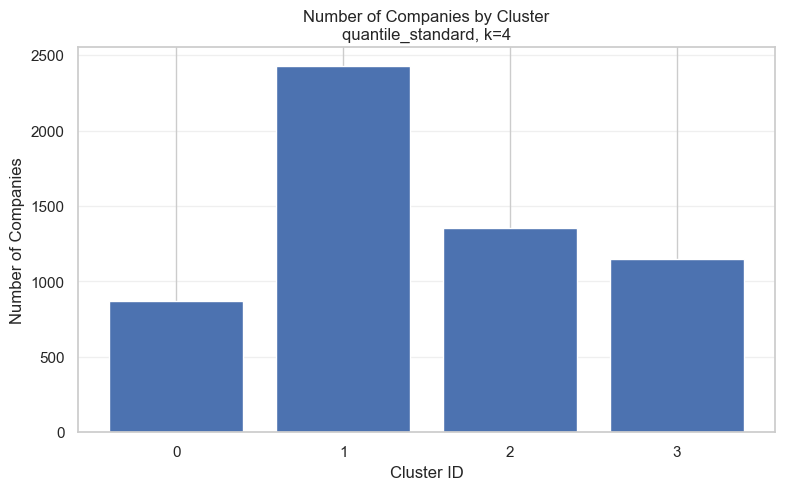

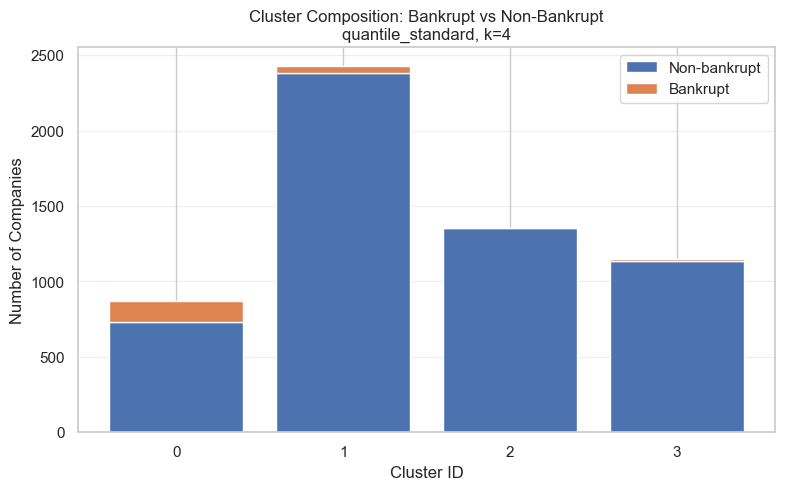

Bankruptcy rates by cluster:
cluster 0: total=872, bankrupt=140, rate=0.1606
cluster 1: total=2432, bankrupt=50, rate=0.0206
cluster 2: total=1357, bankrupt=0, rate=0.0000
cluster 3: total=1146, bankrupt=8, rate=0.0070

CLUSTER DISTRIBUTION: preprocessing=quantile_standard, k=5


,cluster_id,total_companies,bankrupt_companies,non_bankrupt_companies,bankruptcy_rate
0,0,1239,14,1225,0.011299
1,1,851,141,710,0.165687
2,2,1527,36,1491,0.023576
3,3,1285,0,1285,0.000000
4,4,905,7,898,0.007735


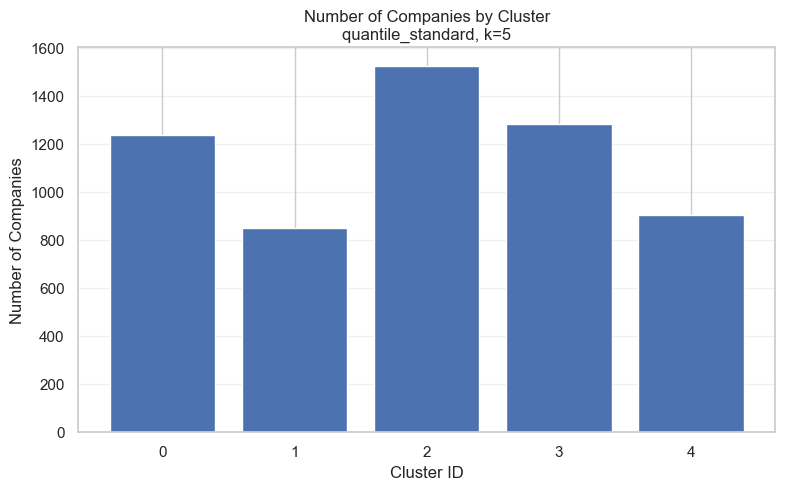

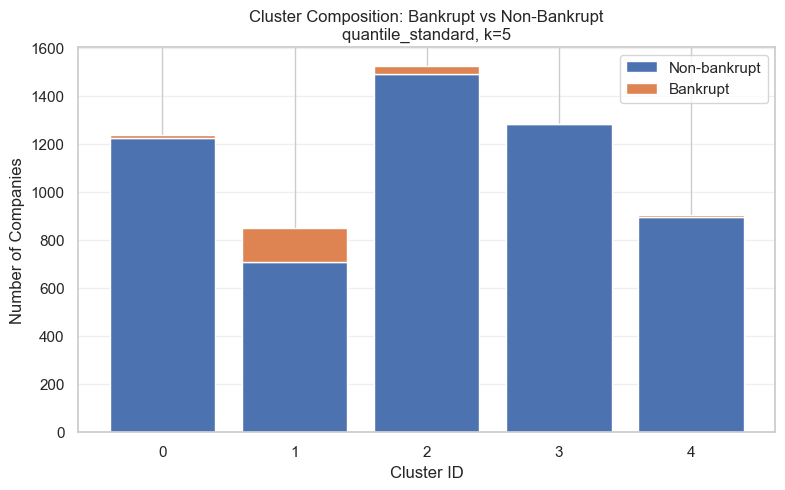

Bankruptcy rates by cluster:
cluster 0: total=1239, bankrupt=14, rate=0.0113
cluster 1: total=851, bankrupt=141, rate=0.1657
cluster 2: total=1527, bankrupt=36, rate=0.0236
cluster 3: total=1285, bankrupt=0, rate=0.0000
cluster 4: total=905, bankrupt=7, rate=0.0077



In [16]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans

# =========================================================
# Passing KMeans solutions from the sweep
# =========================================================
passing_solutions = [
    ('quantile_standard', 4),
    ('quantile_standard', 5)
]

for preprocessing_name, k in passing_solutions:
    # transform data with the already-defined preprocessing pipeline
    transformed = preprocessing_candidates[preprocessing_name].fit_transform(X_stage1)

    # fit KMeans for the selected solution
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=SEED)
    labels = pd.Series(
        kmeans.fit_predict(transformed),
        index=X_stage1.index,
        name='cluster_id'
    )

    # cluster summaries
    total_count_by_cluster = y.groupby(labels).size().sort_index()
    bankrupt_count_by_cluster = y.groupby(labels).sum().sort_index()
    non_bankrupt_count_by_cluster = total_count_by_cluster - bankrupt_count_by_cluster
    bankruptcy_rate_by_cluster = (bankrupt_count_by_cluster / total_count_by_cluster).sort_index()

    summary_df = pd.DataFrame({
        'cluster_id': total_count_by_cluster.index.astype(int),
        'total_companies': total_count_by_cluster.values.astype(int),
        'bankrupt_companies': bankrupt_count_by_cluster.values.astype(int),
        'non_bankrupt_companies': non_bankrupt_count_by_cluster.values.astype(int),
        'bankruptcy_rate': bankruptcy_rate_by_cluster.values
    }).sort_values('cluster_id').reset_index(drop=True)

    print('=' * 100)
    print(f'CLUSTER DISTRIBUTION: preprocessing={preprocessing_name}, k={k}')
    print('=' * 100)
    display(summary_df)

    # -----------------------------------------------------
    # Plot 1: total companies by cluster
    # -----------------------------------------------------
    plt.figure(figsize=(9, 5))
    plt.bar(summary_df['cluster_id'].astype(str), summary_df['total_companies'])
    plt.title(f'Number of Companies by Cluster\n{preprocessing_name}, k={k}')
    plt.xlabel('Cluster ID')
    plt.ylabel('Number of Companies')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    # -----------------------------------------------------
    # Plot 2: bankrupt vs non-bankrupt by cluster
    # -----------------------------------------------------
    plt.figure(figsize=(9, 5))
    plt.bar(summary_df['cluster_id'].astype(str), summary_df['non_bankrupt_companies'], label='Non-bankrupt')
    plt.bar(
        summary_df['cluster_id'].astype(str),
        summary_df['bankrupt_companies'],
        bottom=summary_df['non_bankrupt_companies'],
        label='Bankrupt'
    )
    plt.title(f'Cluster Composition: Bankrupt vs Non-Bankrupt\n{preprocessing_name}, k={k}')
    plt.xlabel('Cluster ID')
    plt.ylabel('Number of Companies')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    # optional textual summary
    print('Bankruptcy rates by cluster:')
    for _, row in summary_df.iterrows():
        print(
            f"cluster {int(row['cluster_id'])}: "
            f"total={int(row['total_companies'])}, "
            f"bankrupt={int(row['bankrupt_companies'])}, "
            f"rate={row['bankruptcy_rate']:.4f}"
        )
    print()